# Sensitivity Analysis 2 — Refined Damping Values

Analyses 175 OrcaFlex simulations across 5 wave directions (0°, 45°, 90°, 135°, 180°).

**Per simulation:**
- Time series centered around its own mean (response = raw − mean)
- Significant amplitude (mean of highest 1/3 peaks)
- Standard deviation (from OrcaFlex)
- % difference vs reference case (all low) per seastate + direction

**Outputs:**
- `sensitivity_results.xlsx` — all results with % differences
- `sensitivity_summary.xlsx` — mean |% diff| per varied DOF, per direction
- `sensitivity_ranking.xlsx` — cases ranked by response per DOF
- PNG plots — time series, bar charts, heatmaps, scatter, % vs Tp


In [40]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

print('Imports OK')

TITLE_SIZE = 18
LABEL_SIZE = 15
TICK_SIZE = 13

Imports OK


In [13]:
# ============================================================
# 2. Paths
# ============================================================
INPUT_FILE   = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulaties_sensitvities1_2\Input_sensitivity1_2.xlsx")
RESULTS_FILE = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulaties_sensitvities1_2\Results_sensitivity1_2.xlsx")

OUTPUT_DIR   = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulaties_sensitvities1_2\analysis")
PLOTS_DIR    = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Time-series plot range [s]
T_PLOT_START = 200.0
T_PLOT_END   = 300.0
DT           = 0.1

# Natural periods
NAT_PERIODS = {'heave': 4.08, 'pitch': 7.10, 'roll': 7.08}

# Per-direction excluded DOFs (motion too small)
DIR_SKIP_DOF = {0: ['roll'], 90: ['pitch'], 180: ['roll'], 45: [], 135: []}

print('Paths set')

Paths set


In [14]:
# ============================================================
# 3. Load input (case metadata)
# ============================================================
inp = pd.read_excel(INPUT_FILE, header=1)
inp.columns = [
    '%filename', '%Hs', '%Tp', '%Tz', '%Direction',
    '%Damp_Heave', '%Damp_Roll', '%Damp_Pitch',
    '%Lin_Heave',  '%Quad_Heave',
    '%Lin_Roll',   '%Quad_Roll',
    '%Lin_Pitch',  '%Quad_Pitch',
    'extra',
][:inp.shape[1]]

meta = inp.dropna(subset=['%Hs']).reset_index(drop=True)
print(f'Total cases in input: {len(meta)}')
print(f'Directions: {sorted(meta["%Direction"].unique())}')
meta[['%filename', '%Hs', '%Tp', '%Direction', '%Damp_Heave', '%Damp_Roll', '%Damp_Pitch']].head(5)

Total cases in input: 175
Directions: [np.int64(0), np.int64(45), np.int64(90), np.int64(135), np.int64(180)]


,%filename,%Hs,%Tp,%Direction,%Damp_Heave,%Damp_Roll,%Damp_Pitch
0,ymlfiles\Case_000_H2_T4.08_dir0_heavelow_pitch...,2,4.08,0,low,low,low
1,ymlfiles\Case_001_H2_T4.08_dir0_heavelinhigh_p...,2,4.08,0,linhigh,low,low
2,ymlfiles\Case_002_H2_T4.08_dir0_heavequadhigh_...,2,4.08,0,quadhigh,low,low
3,ymlfiles\Case_003_H2_T4.08_dir0_heavelow_pitch...,2,4.08,0,low,linhigh,low
4,ymlfiles\Case_004_H2_T4.08_dir0_heavelow_pitch...,2,4.08,0,low,quadhigh,low


In [15]:
# ============================================================
# 4. Load results
# Structure: per sim 9 columns:
#   0=Heave_ts, 1=Roll_ts, 2=Pitch_ts (Z, Rotation1, Rotation2)
#   3=Heave_mean, 4=Roll_mean, 5=Pitch_mean
#   6=Heave_std, 7=Roll_std, 8=Pitch_std
# Row 0 has the statistic values; rows 1+ have time-series values
# ============================================================
res_raw = pd.read_excel(RESULTS_FILE, header=0)
n_cols  = res_raw.shape[1]
cols_per_sim = 9
n_sims  = n_cols // cols_per_sim

print(f'Results columns: {n_cols}  →  {n_sims} complete simulations')
print(f'Input cases:     {len(meta)}')
if n_sims < len(meta):
    print(f'WARNING: {len(meta) - n_sims} cases missing from results file')

n_rows = res_raw.shape[0]
time   = np.arange(n_rows) * DT
print(f'Time series length: {n_rows} steps  →  {n_rows * DT:.1f} s')

Results columns: 1575  →  175 complete simulations
Input cases:     175
Time series length: 3081 steps  →  308.1 s


In [16]:
# ============================================================
# 5. Significant amplitude helper
# ============================================================
def significant_amplitude(ts: np.ndarray) -> float:
    """Mean of the highest 1/3 of |peaks|. Expects a centered (zero-mean) signal."""
    ts = np.asarray(ts, dtype=float)
    ts = ts[~np.isnan(ts)]
    if len(ts) < 3:
        return np.nan

    peaks_idx, _ = find_peaks(np.abs(ts))
    if len(peaks_idx) == 0:
        return np.nan

    peak_vals = np.sort(np.abs(ts[peaks_idx]))[::-1]
    n_top     = max(1, len(peak_vals) // 3)
    return float(np.mean(peak_vals[:n_top]))

print('significant_amplitude() defined')

significant_amplitude() defined


In [17]:
# ============================================================
# 6. Parse all results — center each time series around its mean
# ============================================================
records = []

for sim_idx in range(n_sims):
    c = sim_idx * cols_per_sim

    # Raw time series (skip row 0 — that contains the statistic)
    heave_raw = res_raw.iloc[1:, c + 0].values.astype(float)
    roll_raw  = res_raw.iloc[1:, c + 1].values.astype(float)
    pitch_raw = res_raw.iloc[1:, c + 2].values.astype(float)

    # OrcaFlex statistics (row 0)
    heave_mean = res_raw.iloc[0, c + 3]
    roll_mean  = res_raw.iloc[0, c + 4]
    pitch_mean = res_raw.iloc[0, c + 5]
    heave_std  = res_raw.iloc[0, c + 6]
    roll_std   = res_raw.iloc[0, c + 7]
    pitch_std  = res_raw.iloc[0, c + 8]

    # Center each time series around its own mean
    heave_ts = heave_raw - heave_mean
    roll_ts  = roll_raw  - roll_mean
    pitch_ts = pitch_raw - pitch_mean

    # Significant amplitude on the centered signals
    heave_sa = significant_amplitude(heave_ts)
    roll_sa  = significant_amplitude(roll_ts)
    pitch_sa = significant_amplitude(pitch_ts)

    # Metadata
    m = meta.iloc[sim_idx] if sim_idx < len(meta) else {}

    records.append({
        'sim_idx':       sim_idx,
        'filename':      m.get('%filename',    f'sim_{sim_idx:03d}'),
        'Hs':            m.get('%Hs'),
        'Tp':            m.get('%Tp'),
        'Tz':            m.get('%Tz'),
        'Direction':     m.get('%Direction'),
        'Damp_Heave':    m.get('%Damp_Heave'),
        'Damp_Roll':     m.get('%Damp_Roll'),
        'Damp_Pitch':    m.get('%Damp_Pitch'),
        'Lin_Heave':     m.get('%Lin_Heave'),
        'Quad_Heave':    m.get('%Quad_Heave'),
        'Lin_Roll':      m.get('%Lin_Roll'),
        'Quad_Roll':     m.get('%Quad_Roll'),
        'Lin_Pitch':     m.get('%Lin_Pitch'),
        'Quad_Pitch':    m.get('%Quad_Pitch'),
        'heave_mean':    heave_mean,
        'roll_mean':     roll_mean,
        'pitch_mean':    pitch_mean,
        'heave_std':     heave_std,
        'roll_std':      roll_std,
        'pitch_std':     pitch_std,
        'heave_sig_amp': heave_sa,
        'roll_sig_amp':  roll_sa,
        'pitch_sig_amp': pitch_sa,
        '_heave_ts':     heave_ts,
        '_roll_ts':      roll_ts,
        '_pitch_ts':     pitch_ts,
    })

results = pd.DataFrame(records)
print(f'Parsed {len(results)} simulations')
results[['filename', 'Hs', 'Tp', 'Direction',
         'heave_sig_amp', 'heave_std',
         'pitch_sig_amp', 'pitch_std',
         'roll_sig_amp',  'roll_std']].head(7)

Parsed 175 simulations


,filename,Hs,Tp,Direction,heave_sig_amp,heave_std,pitch_sig_amp,pitch_std,roll_sig_amp,roll_std
0,ymlfiles\Case_000_H2_T4.08_dir0_heavelow_pitch...,2,4.08,0,0.276598,0.151422,3.565618,1.758229,0.002220,0.001255
1,ymlfiles\Case_001_H2_T4.08_dir0_heavelinhigh_p...,2,4.08,0,0.252117,0.139586,3.569085,1.759908,0.003369,0.001880
2,ymlfiles\Case_002_H2_T4.08_dir0_heavequadhigh_...,2,4.08,0,0.272902,0.149584,3.566264,1.758537,0.004688,0.003749
3,ymlfiles\Case_003_H2_T4.08_dir0_heavelow_pitch...,2,4.08,0,0.276595,0.151423,3.565526,1.758202,0.002082,0.001196
4,ymlfiles\Case_004_H2_T4.08_dir0_heavelow_pitch...,2,4.08,0,0.276598,0.151422,3.565618,1.758229,0.002220,0.001255
5,ymlfiles\Case_005_H2_T4.08_dir0_heavelow_pitch...,2,4.08,0,0.276509,0.151481,3.529019,1.737755,0.002553,0.001514
6,ymlfiles\Case_006_H2_T4.08_dir0_heavelow_pitch...,2,4.08,0,0.276405,0.151411,3.544295,1.748530,0.002546,0.001346


In [18]:
# ============================================================
# 7. % difference vs reference (all low) per seastate+direction
# ============================================================
is_ref = (
    (results['Damp_Heave'] == 'low') &
    (results['Damp_Roll']  == 'low') &
    (results['Damp_Pitch'] == 'low')
)

ref_df  = results[is_ref].set_index(['Hs', 'Tp', 'Direction'])
metrics = ['heave_sig_amp', 'heave_std', 'pitch_sig_amp', 'pitch_std', 'roll_sig_amp', 'roll_std']

for metric in metrics:
    pct_col = f'{metric}_pct'
    results[pct_col] = results.apply(
        lambda row: (
            (row[metric] - ref_df.loc[(row['Hs'], row['Tp'], row['Direction']), metric])
            / ref_df.loc[(row['Hs'], row['Tp'], row['Direction']), metric] * 100
            if (row['Hs'], row['Tp'], row['Direction']) in ref_df.index else np.nan
        ),
        axis=1,
    )

non_ref = results[~is_ref].copy()
print('% differences calculated')
print(f'Reference cases: {is_ref.sum()}   Non-reference cases: {(~is_ref).sum()}')

% differences calculated
Reference cases: 25   Non-reference cases: 150


In [19]:
# ============================================================
# 8. Save full results to Excel
# ============================================================
export_cols = [c for c in results.columns if not c.startswith('_')]
results[export_cols].to_excel(OUTPUT_DIR / 'sensitivity_results.xlsx', index=False)
print(f'Saved → {OUTPUT_DIR / "sensitivity_results.xlsx"}')

Saved → C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulaties_sensitvities1_2\analysis\sensitivity_results.xlsx


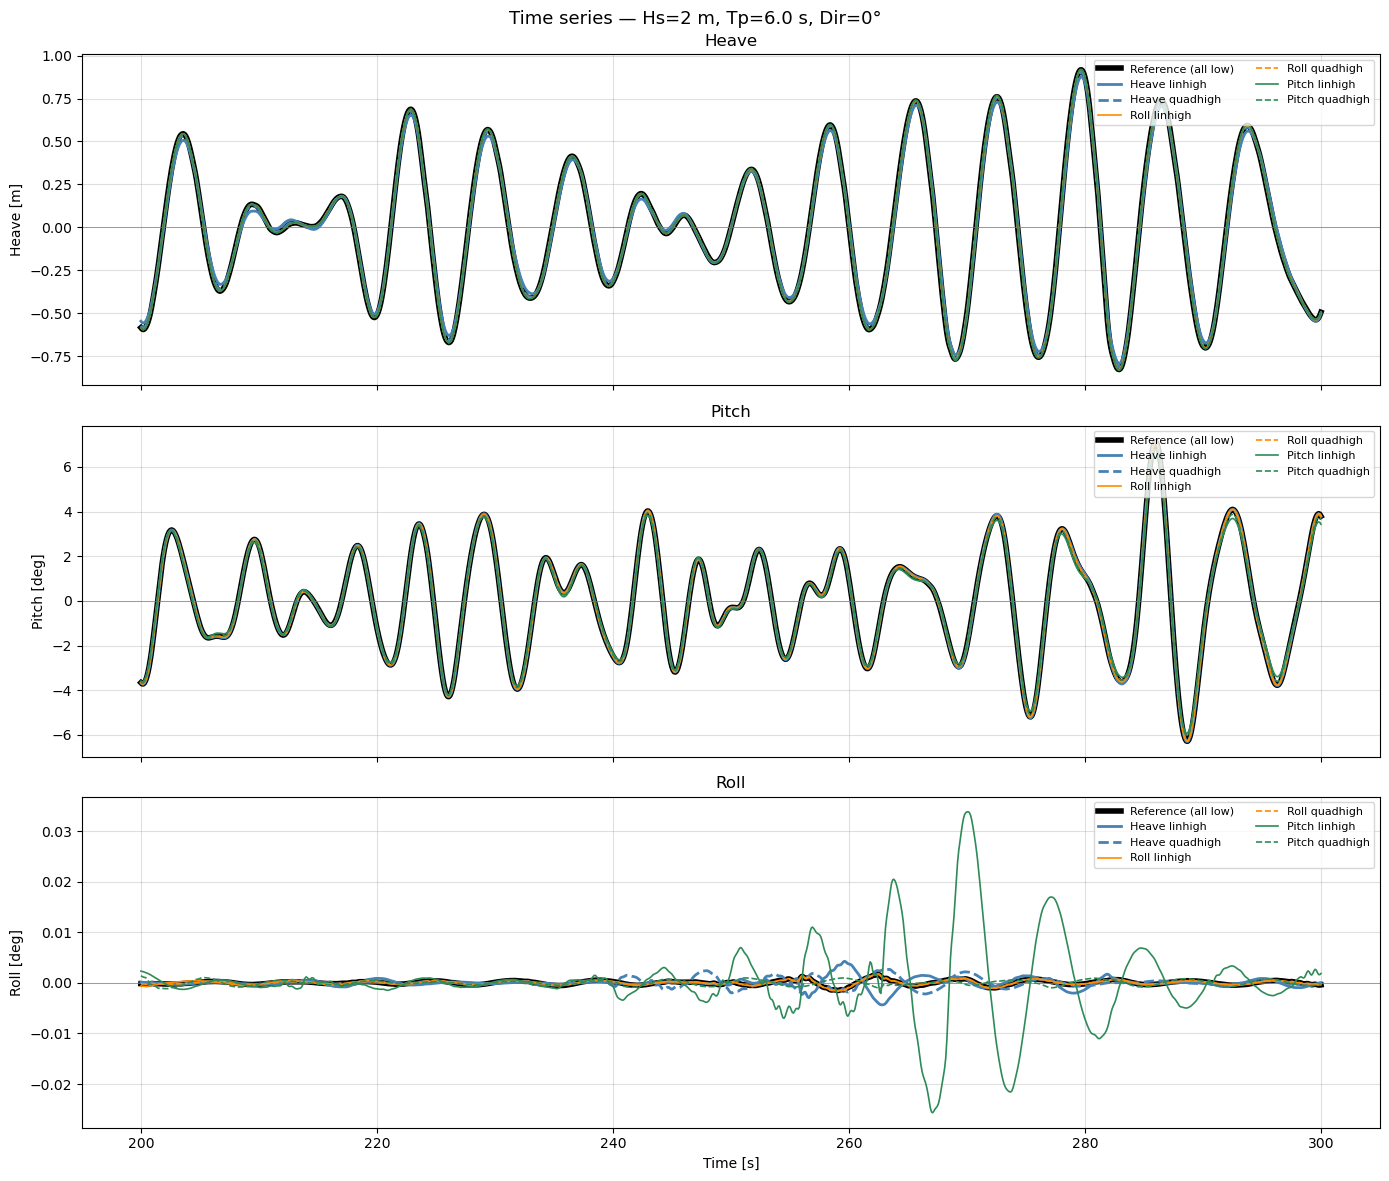

Saved: ts_bydof_Hs2_Tp6.0_dir0.png


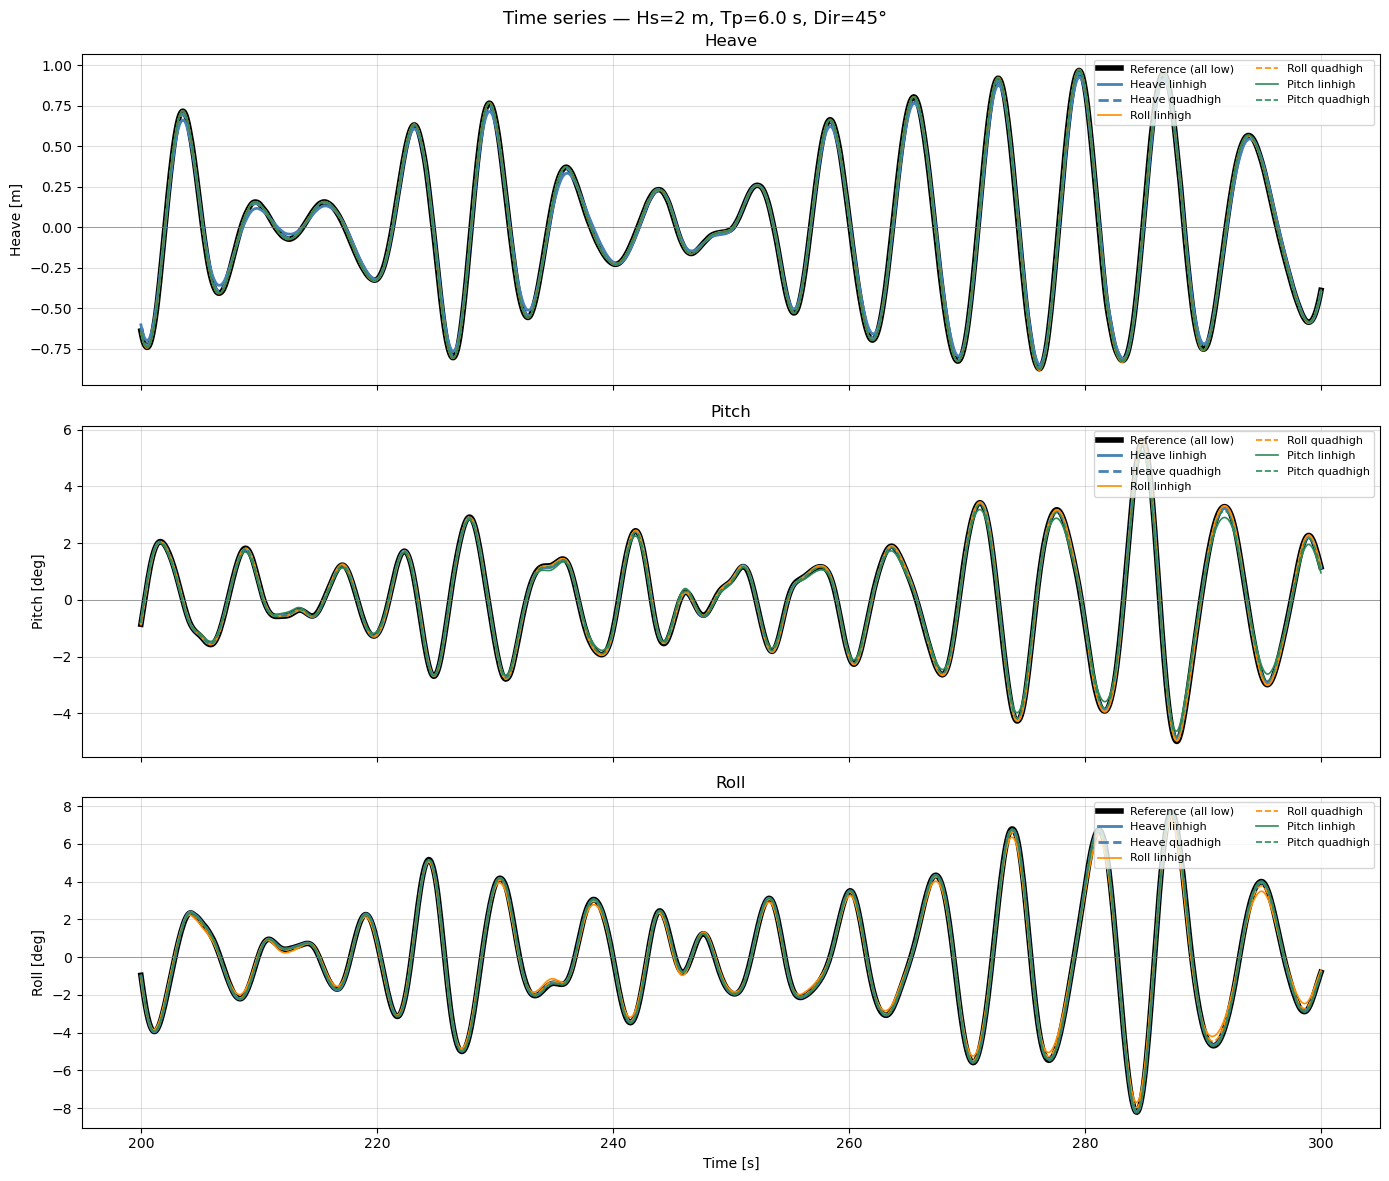

Saved: ts_bydof_Hs2_Tp6.0_dir45.png


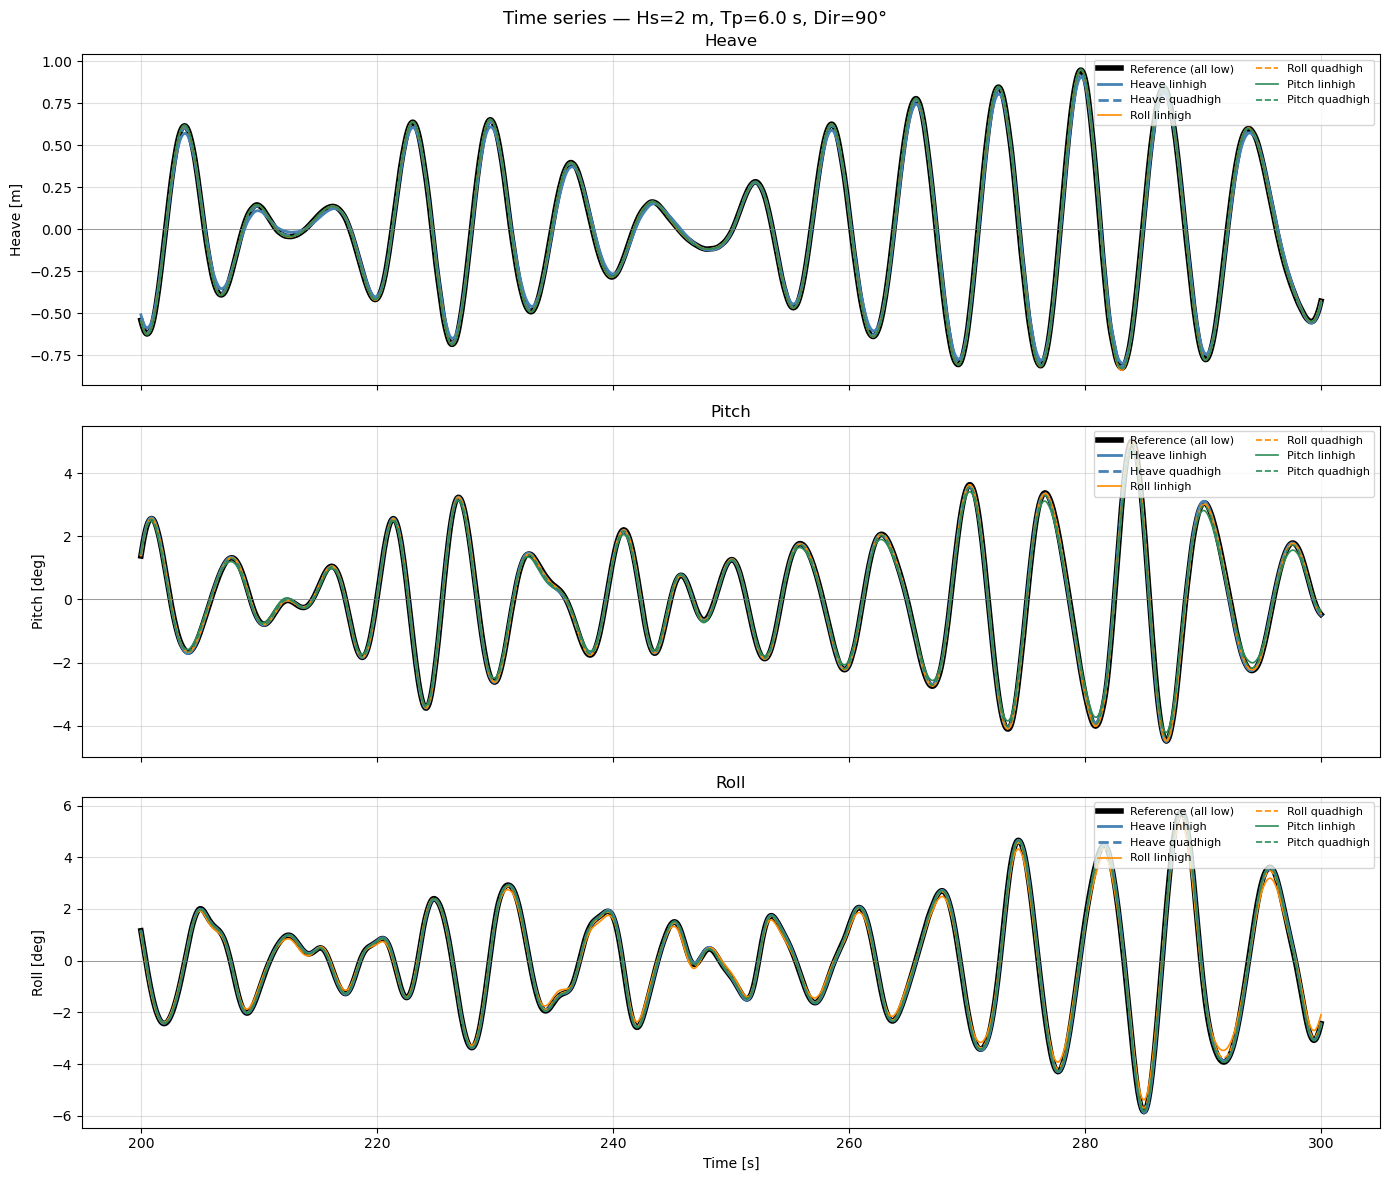

Saved: ts_bydof_Hs2_Tp6.0_dir90.png


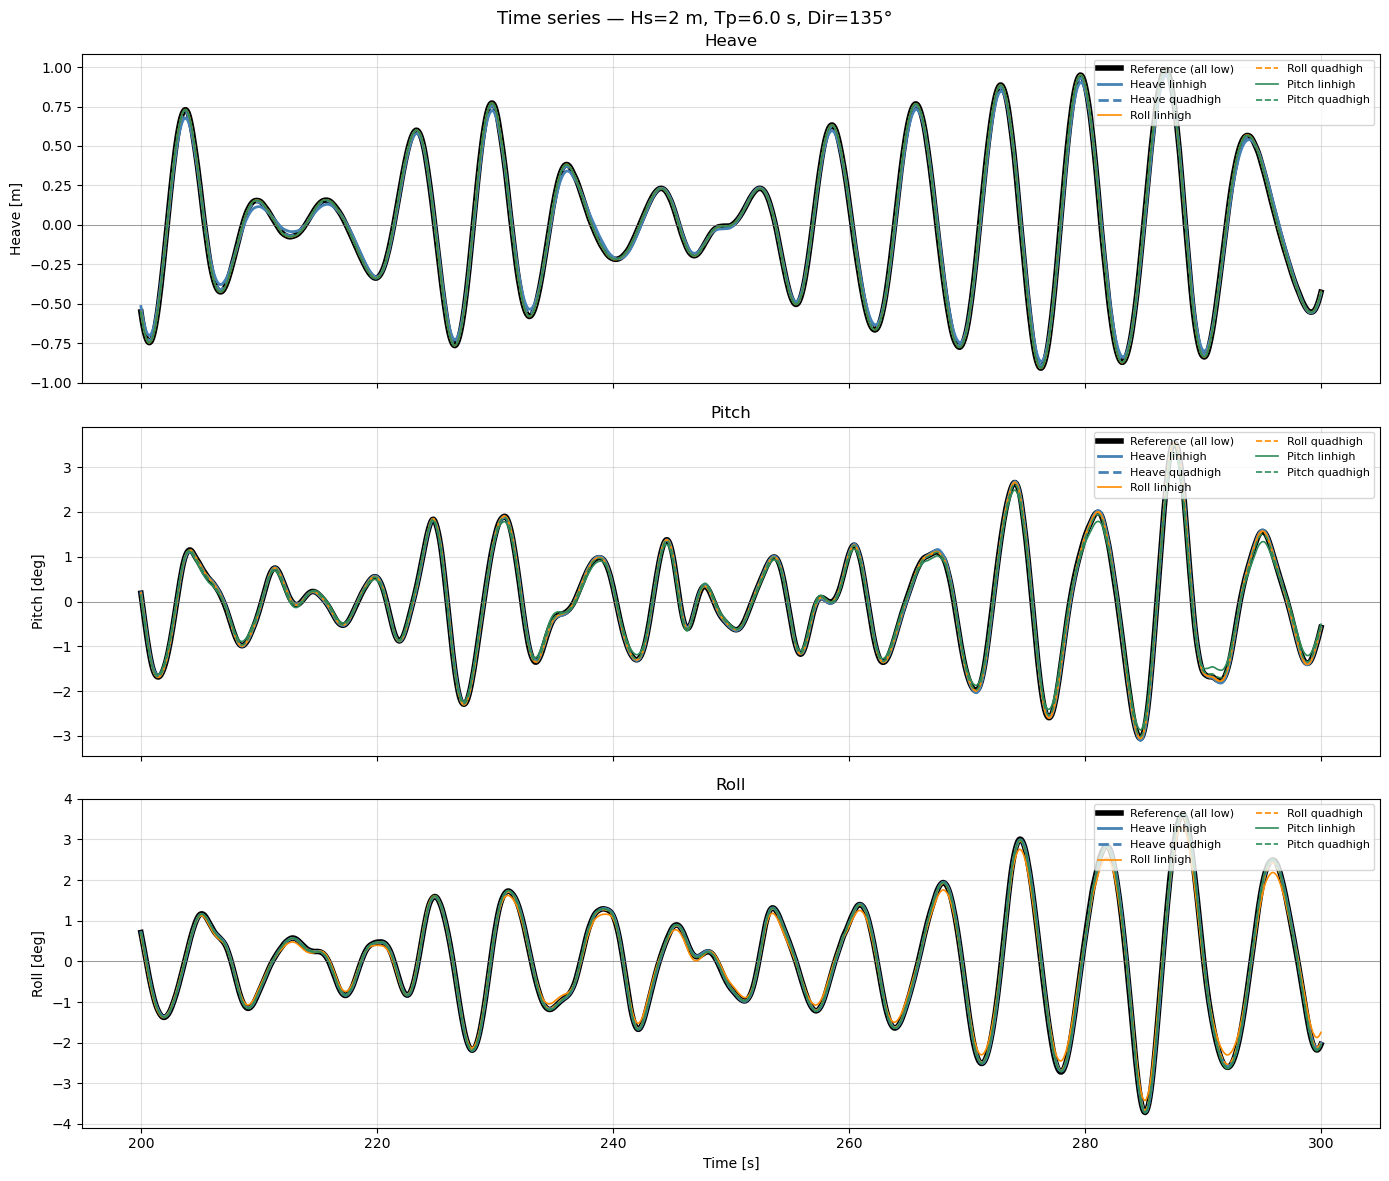

Saved: ts_bydof_Hs2_Tp6.0_dir135.png


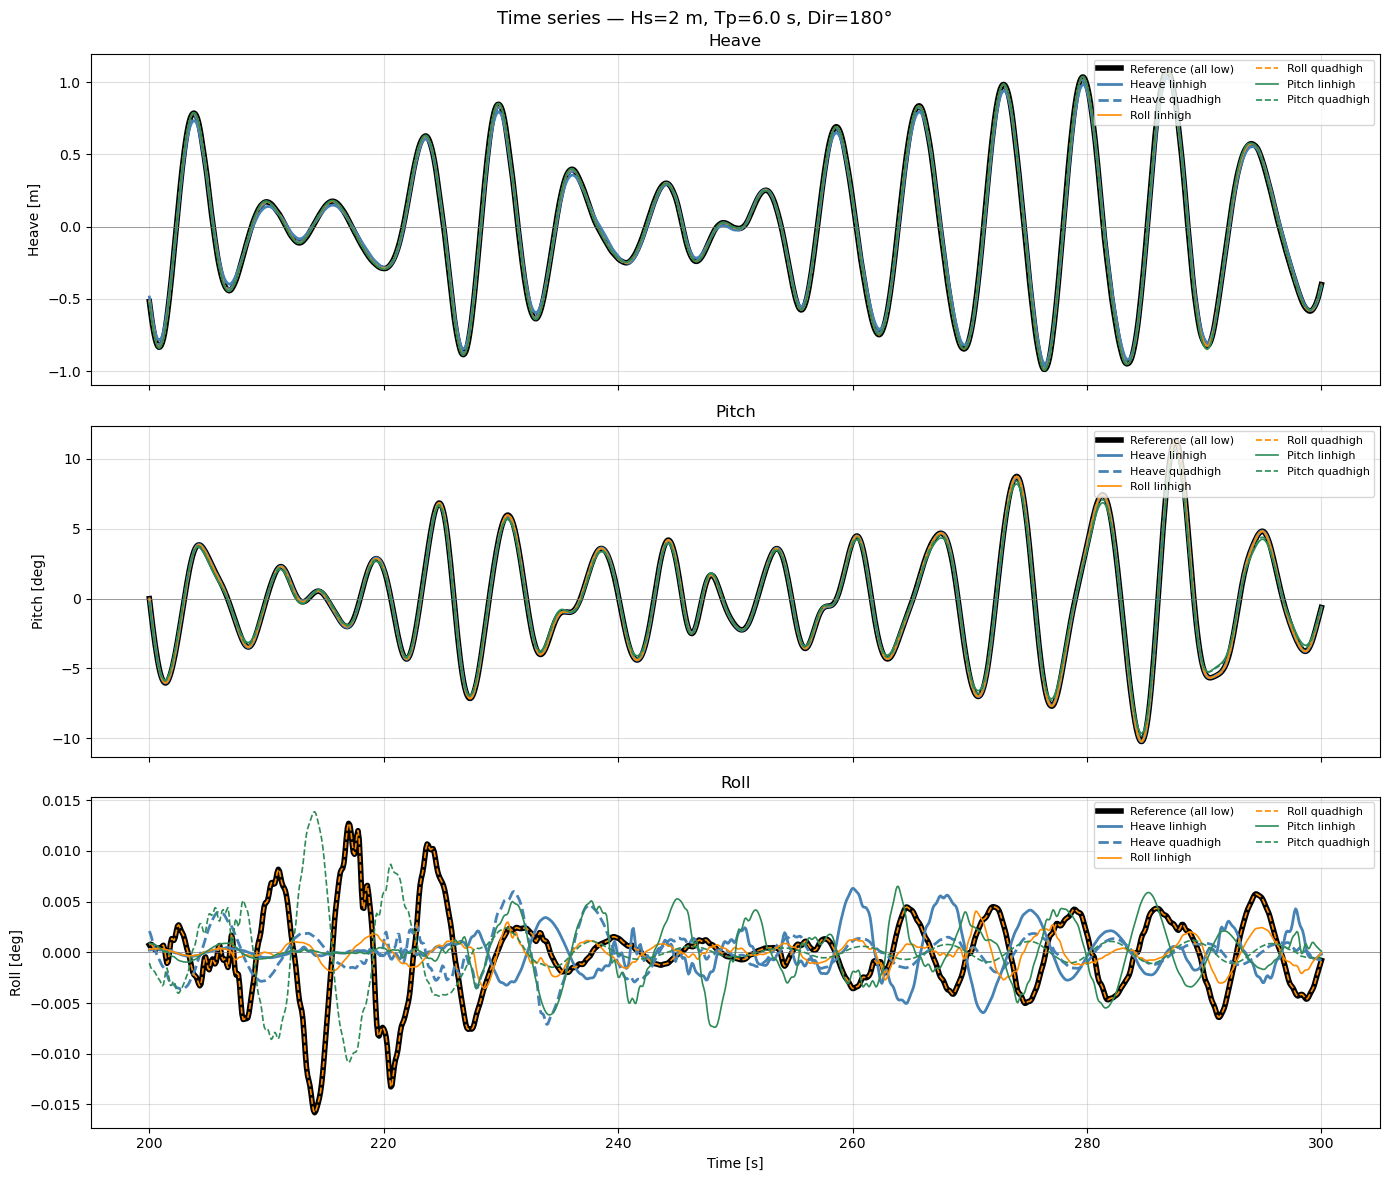

Saved: ts_bydof_Hs2_Tp6.0_dir180.png


In [50]:
# ============================================================
# 9. Time series — color per varied DOF, linestyle = lin/quad
#    Selected seastates only
# ============================================================
mask_t = (time[1:] >= T_PLOT_START) & (time[1:] <= T_PLOT_END)
t_plot = time[1:][mask_t]

dof_color_map = {
    'Heave_linhigh':  ('steelblue',  '-',  'Heave linhigh',  2.0,1),
    'Heave_quadhigh': ('steelblue',  '--', 'Heave quadhigh', 2.0,1),
    'Roll_linhigh':   ('darkorange', '-',  'Roll linhigh',   1.2,1),
    'Roll_quadhigh':  ('darkorange', '--', 'Roll quadhigh',  1.2,1),
    'Pitch_linhigh':  ('seagreen',   '-',  'Pitch linhigh',  1.2,1),
    'Pitch_quadhigh': ('seagreen',   '--', 'Pitch quadhigh', 1.2,1),
    'Reference':      ('black',      '-',  'Reference (all low)', 4, 0.4)
}

def case_type(row):
    if row['Damp_Heave'] == 'linhigh':  return 'Heave_linhigh'
    if row['Damp_Heave'] == 'quadhigh': return 'Heave_quadhigh'
    if row['Damp_Roll']  == 'linhigh':  return 'Roll_linhigh'
    if row['Damp_Roll']  == 'quadhigh': return 'Roll_quadhigh'
    if row['Damp_Pitch'] == 'linhigh':  return 'Pitch_linhigh'
    if row['Damp_Pitch'] == 'quadhigh': return 'Pitch_quadhigh'
    return 'Reference'

dof_ts_info = {
    'heave': {'ts_col': '_heave_ts', 'ylabel': 'Heave [m]'},
    'pitch': {'ts_col': '_pitch_ts', 'ylabel': 'Pitch [deg]'},
    'roll':  {'ts_col': '_roll_ts',  'ylabel': 'Roll [deg]'},
}

# Adjust this list to choose which (Hs, Tp) combos to plot
selected_seastates = [(2, 6)]

for (hs, tp, direction), group in results.groupby(['Hs', 'Tp', 'Direction']):
    if (hs, tp) not in selected_seastates:
        continue

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(f'Time series — Hs={hs} m, Tp={tp} s, Dir={int(direction)}°', fontsize=13)

    for ax, (dof, info) in zip(axes, dof_ts_info.items()):
        for _, row in group.iterrows():
            ctype                  = case_type(row)
            color, ls, label, lw, alpha  = dof_color_map[ctype]
            zorder                 = 2 if ctype == 'Reference' else 3

            ax.plot(t_plot, row[info['ts_col']][mask_t],
                    color=color, linestyle=ls, linewidth=lw,
                    label=label, zorder=zorder)

        ax.set_ylabel(info['ylabel'])
        ax.set_title(dof.capitalize())
        ax.grid(True, alpha=0.4)
        ax.axhline(0, color='gray', linewidth=0.5)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(),
                  fontsize=8, loc='upper right', ncol=2)

    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    fname = PLOTS_DIR / f'ts_bydof_Hs{hs}_Tp{tp}_dir{int(direction)}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {fname.name}')

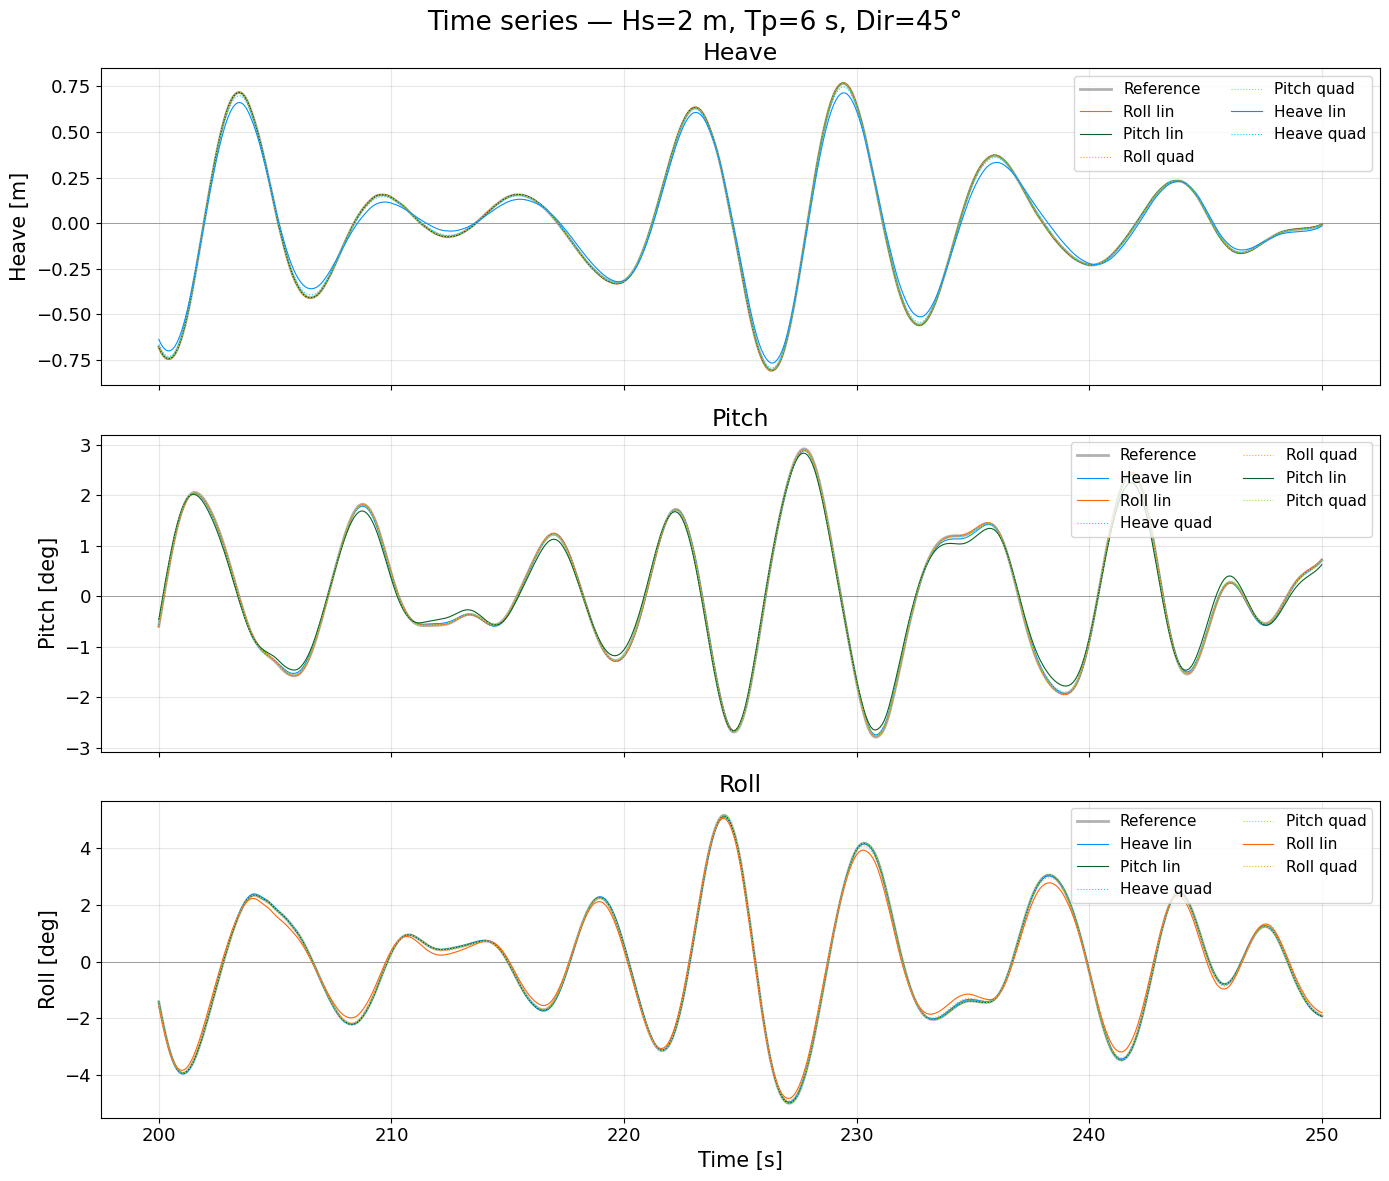

Saved: ts_Hs2_Tp6_dir45.png


In [85]:
# ============================================================
# 9B. Time series — Hs=2, Tp=6, Dir=45
#     Full window: 200-250s
#     Per subplot: eigen DOF damping cases bovenop
# ============================================================
T_SHOW_START = 200.0
T_SHOW_END   = 250.0

target = results[
    (results['Hs'] == 2) &
    (results['Tp'] == 6) &
    (results['Direction'] == 45)
]

ts_len = len(target.iloc[0][dof_ts_info['heave']['ts_col']])
t_ts   = np.arange(ts_len) * DT
mask_t = (t_ts >= T_SHOW_START) & (t_ts <= T_SHOW_END)
t_plot = t_ts[mask_t]

dof_color_map_v2 = {
    'Heave_linhigh':  ("#0091ff", '-',  'Heave lin',  0.8, 1.0),
    'Heave_quadhigh': ('#13d0ff', ':',  'Heave quad', 0.8, 1.0),
    'Roll_linhigh':   ("#ff640b", '-',  'Roll lin',   0.8, 1.0),
    'Roll_quadhigh':  ("#fda624", ':',  'Roll quad',  0.8, 1.0),
    'Pitch_linhigh':  ("#0c6124", '-',  'Pitch lin',  0.8, 1.0),
    'Pitch_quadhigh': ("#92e237", ':',  'Pitch quad', 0.8, 1.0),
    'Reference':      ('black',   '-',  'Reference',  2.0, 0.3),
}

def plot_order_key(row, dof):
    """
    Reference → 0 (achterste laag)
    Andere DOFs solid → 1
    Andere DOFs quad  → 2
    Eigen DOF solid   → 3
    Eigen DOF quad    → 4 (bovenste laag)
    """
    ct = case_type(row)
    if ct == 'Reference':
        return 0
    own = ct.startswith(dof.capitalize())
    is_quad = ct.endswith('quadhigh')
    if own and not is_quad:  return 3
    if own and is_quad:      return 4
    if not own and not is_quad: return 1
    return 2

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Time series — Hs=2 m, Tp=6 s, Dir=45°', fontsize=TITLE_SIZE + 1)

for row_i, (dof, info) in enumerate(dof_ts_info.items()):
    ax = axes[row_i]

    # Re-sort per subplot so own DOF cases are on top
    target_sorted_dof = target.assign(
        _order=target.apply(lambda r: plot_order_key(r, dof), axis=1)
    ).sort_values('_order').drop(columns='_order')

    for _, row in target_sorted_dof.iterrows():
        ctype                       = case_type(row)
        color, ls, label, lw, alpha = dof_color_map_v2[ctype]
        own                         = ctype.startswith(dof.capitalize())
        is_quad                     = ctype.endswith('quadhigh')

        if ctype == 'Reference':   zorder = 1
        elif own and is_quad:      zorder = 5
        elif own and not is_quad:  zorder = 4
        elif is_quad:              zorder = 3
        else:                      zorder = 2

        ts = row[info['ts_col']]
        ax.plot(t_plot, ts[mask_t],
                color=color, linestyle=ls, linewidth=lw,
                label=label, zorder=zorder, alpha=alpha)

    ax.set_ylabel(info['ylabel'], fontsize=LABEL_SIZE)
    ax.set_title(dof.capitalize(), fontsize=LABEL_SIZE + 2)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.5)

    handles, labels_leg = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_leg, handles))
    ax.legend(by_label.values(), by_label.keys(),
              fontsize=TICK_SIZE - 2, loc='upper right', ncol=2)

axes[-1].set_xlabel('Time [s]', fontsize=LABEL_SIZE)
axes[-1].tick_params(axis='x', labelsize=TICK_SIZE)

plt.tight_layout()
fname = PLOTS_DIR / 'ts_Hs2_Tp6_dir45.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved: {fname.name}')

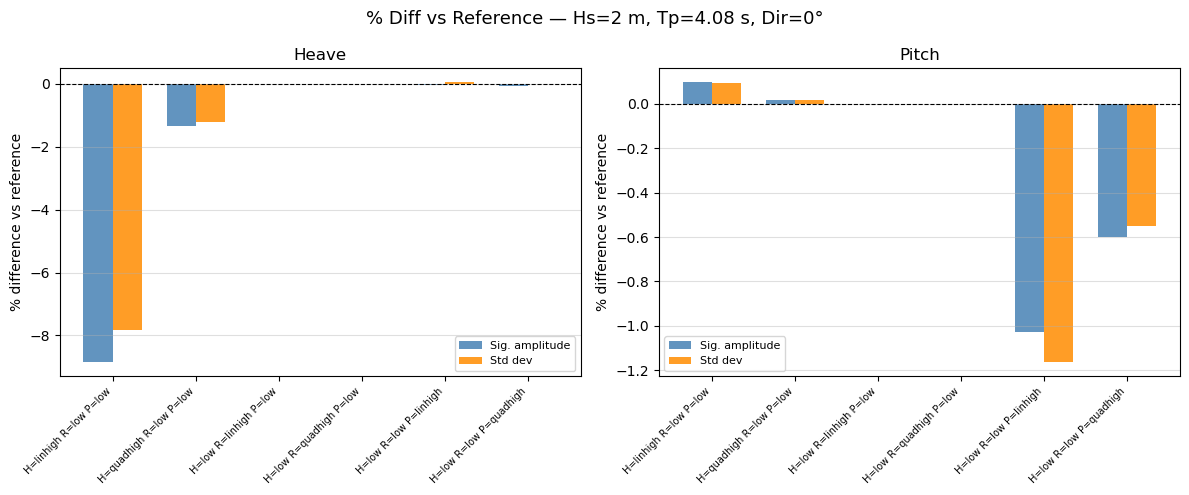

Saved: barchart_Hs2_Tp4.08_dir0.png


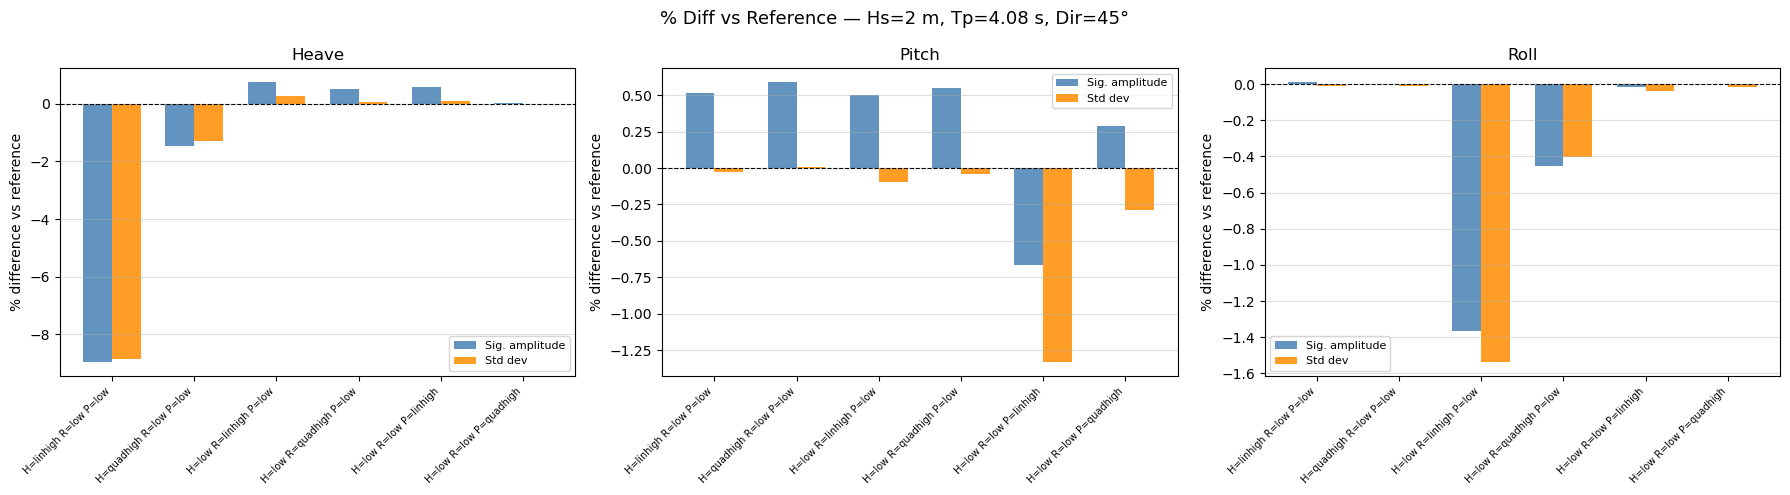

Saved: barchart_Hs2_Tp4.08_dir45.png


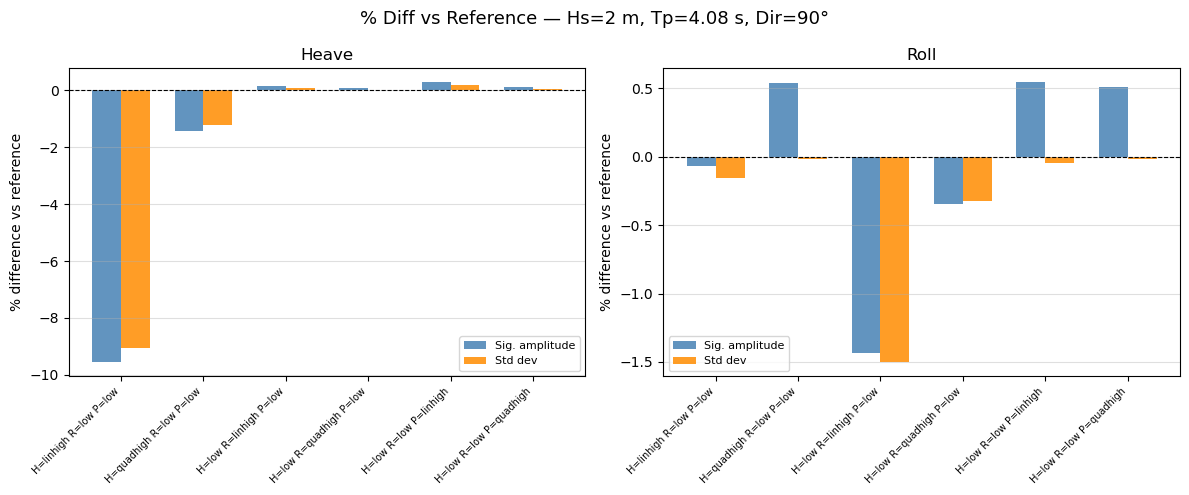

Saved: barchart_Hs2_Tp4.08_dir90.png


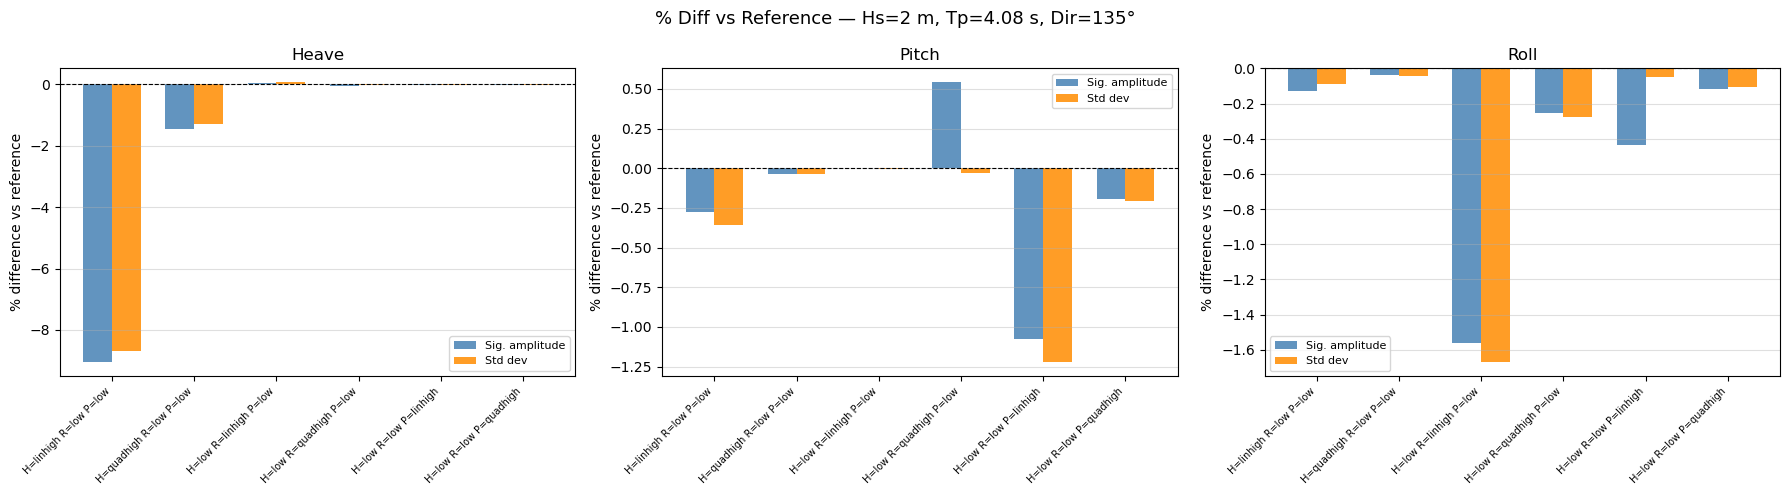

Saved: barchart_Hs2_Tp4.08_dir135.png


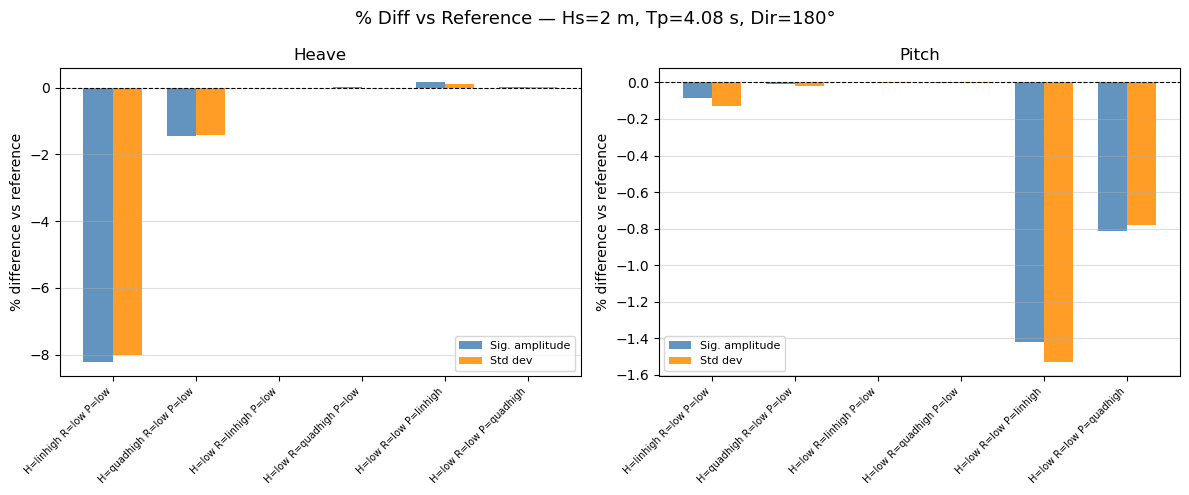

Saved: barchart_Hs2_Tp4.08_dir180.png


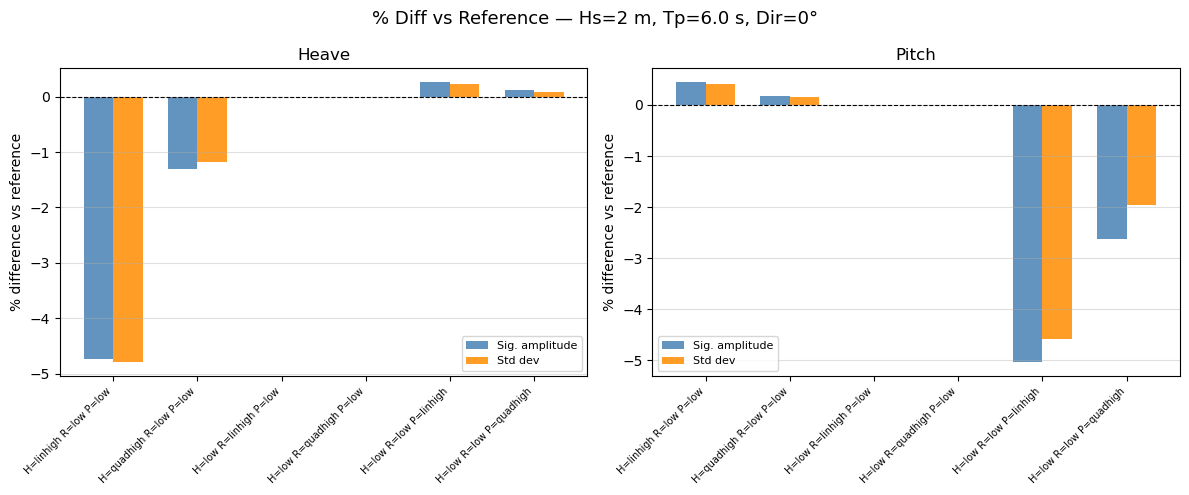

Saved: barchart_Hs2_Tp6.0_dir0.png


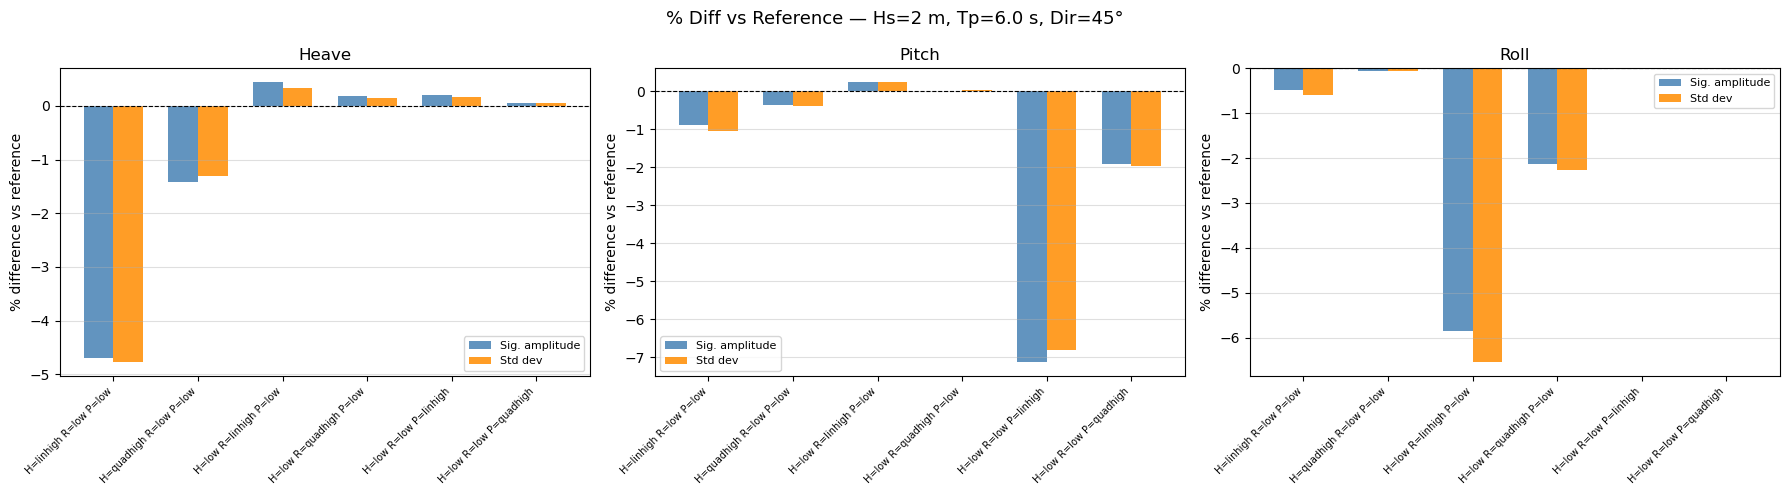

Saved: barchart_Hs2_Tp6.0_dir45.png


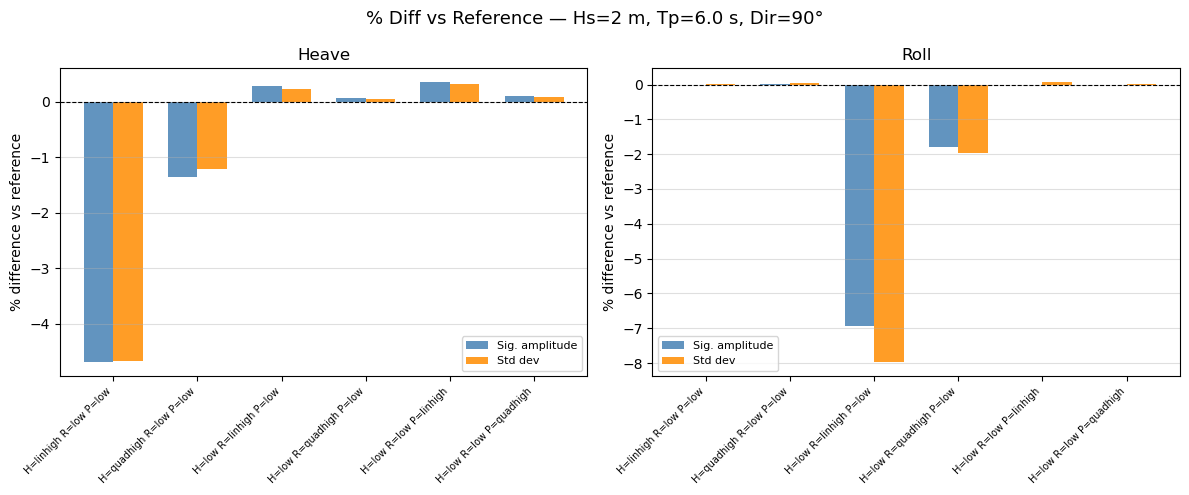

Saved: barchart_Hs2_Tp6.0_dir90.png


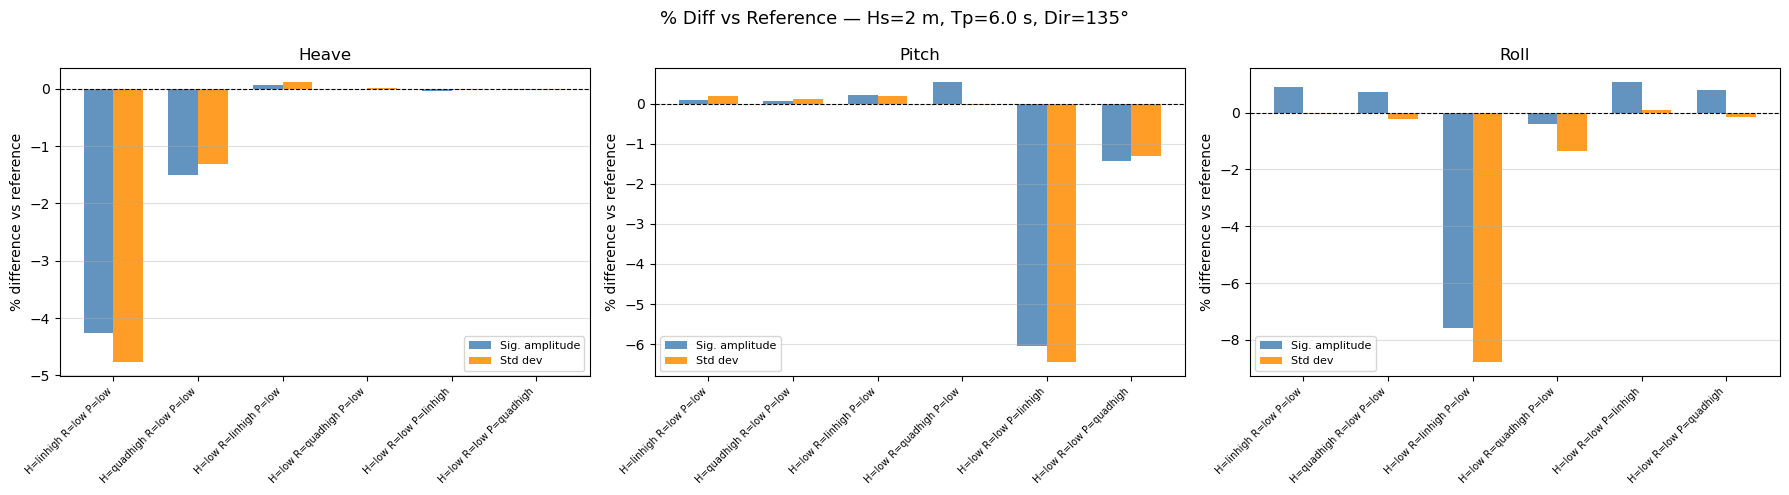

Saved: barchart_Hs2_Tp6.0_dir135.png


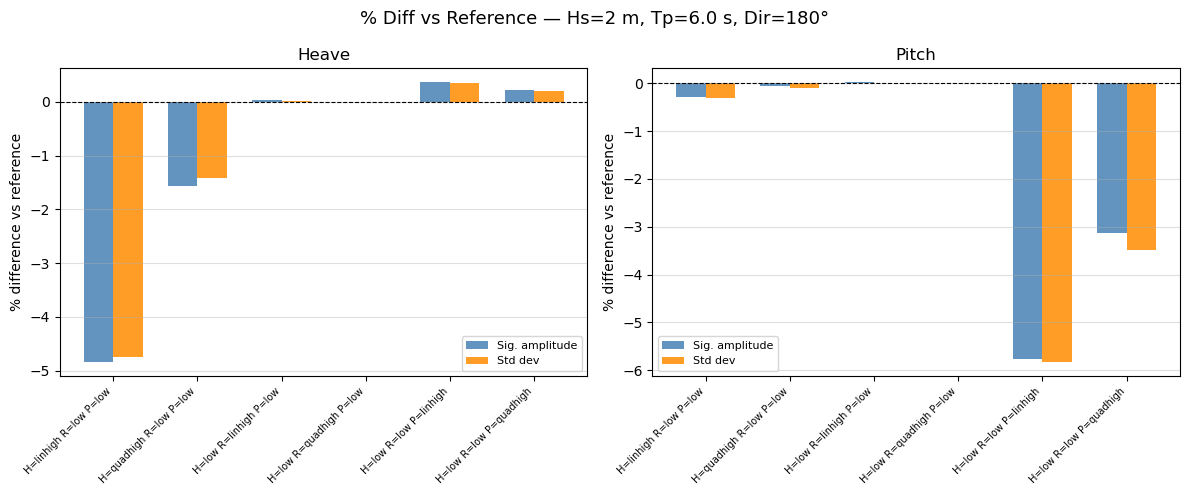

Saved: barchart_Hs2_Tp6.0_dir180.png


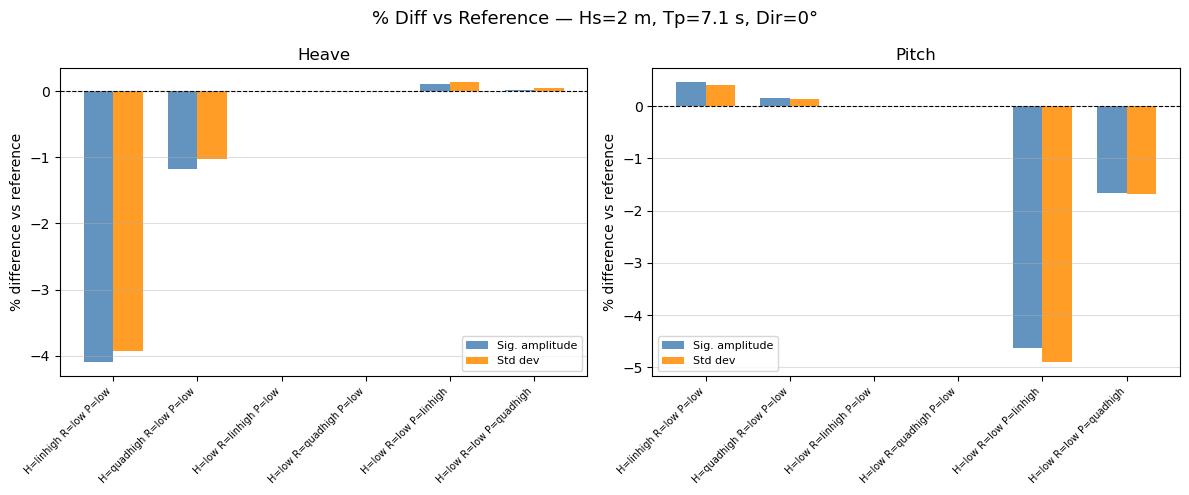

Saved: barchart_Hs2_Tp7.1_dir0.png


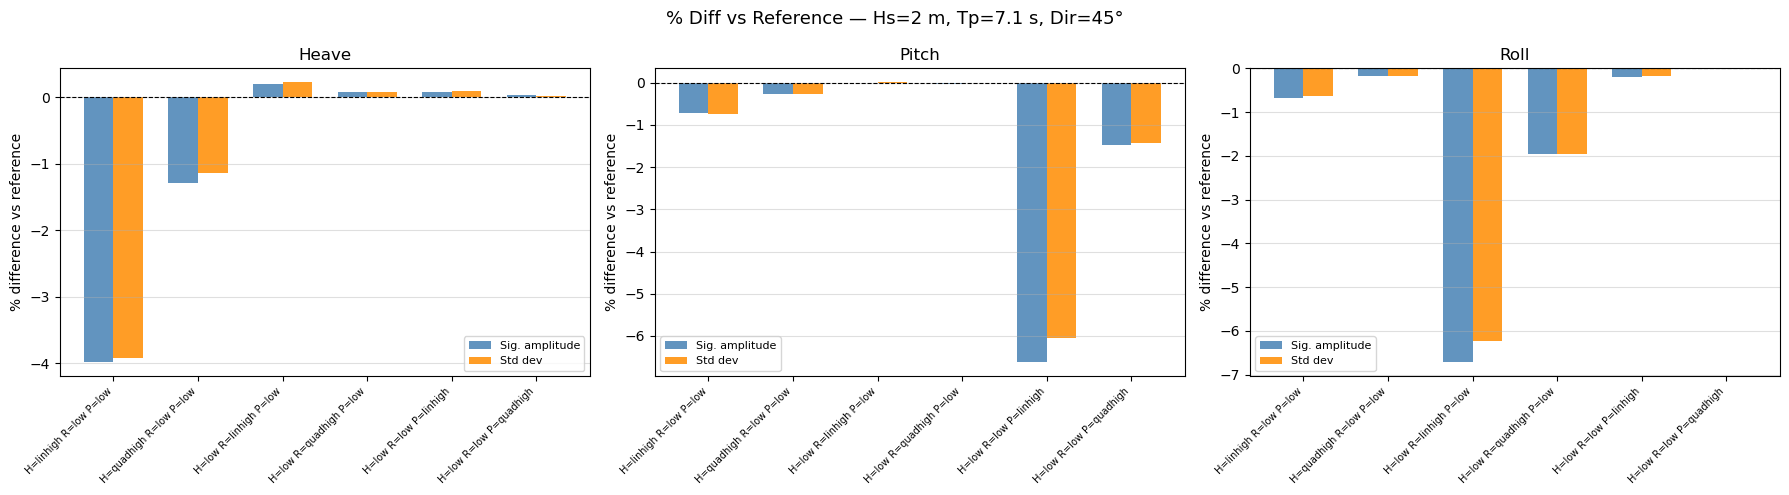

Saved: barchart_Hs2_Tp7.1_dir45.png


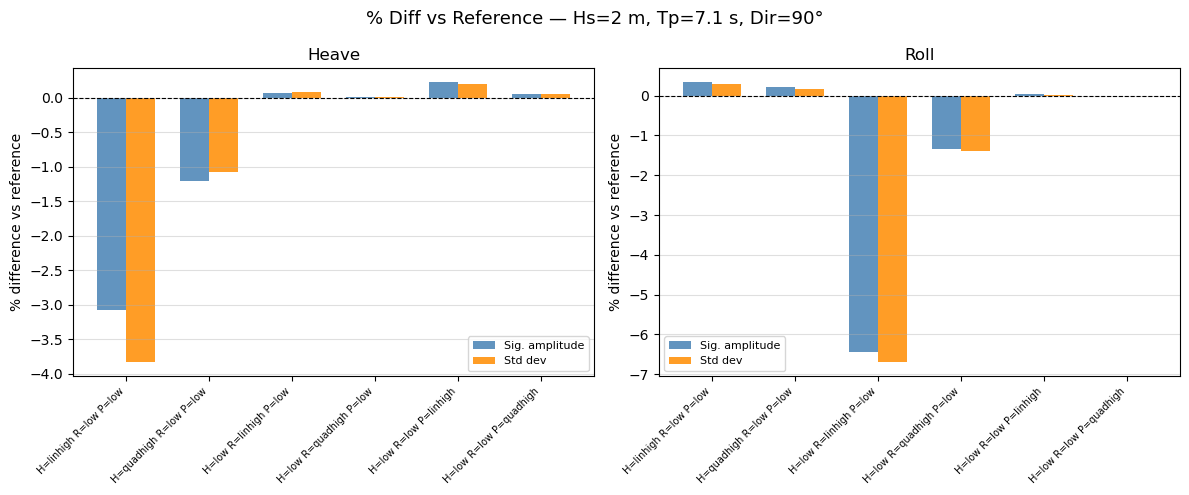

Saved: barchart_Hs2_Tp7.1_dir90.png


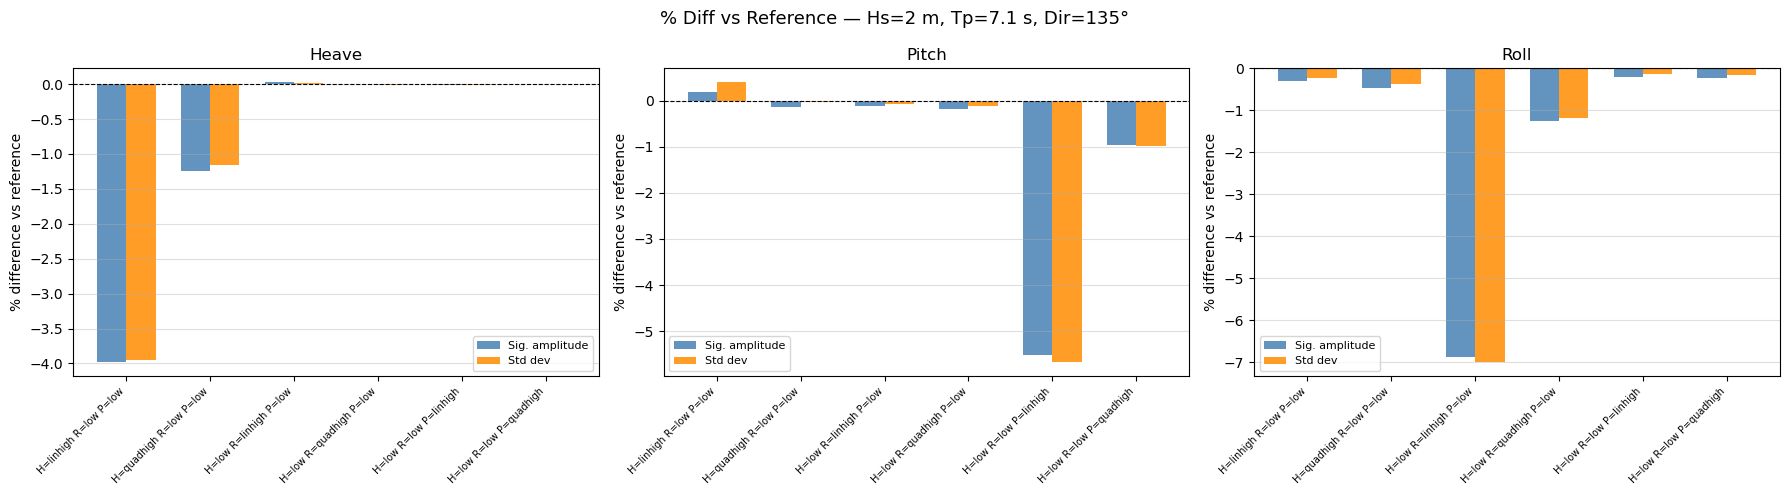

Saved: barchart_Hs2_Tp7.1_dir135.png


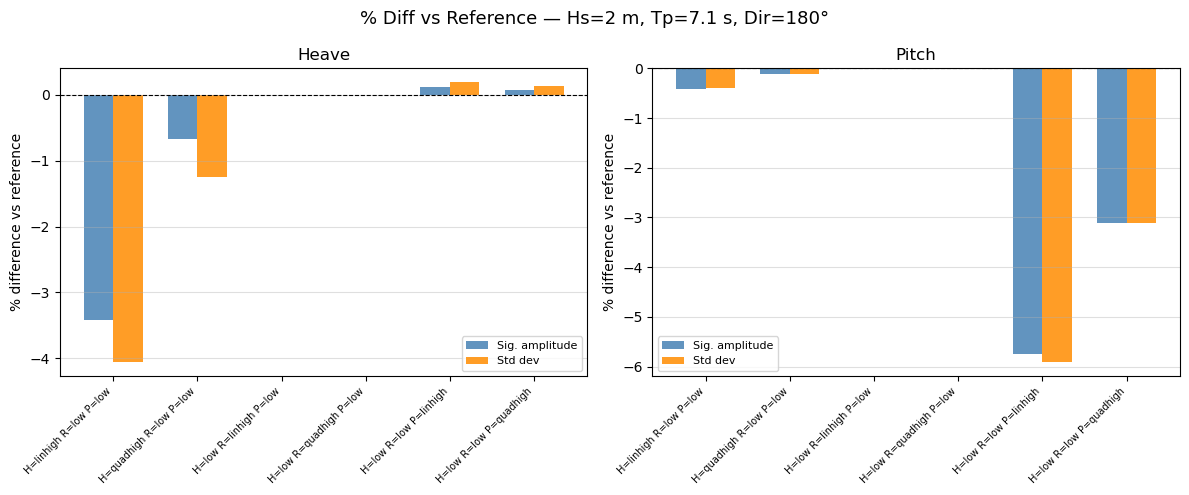

Saved: barchart_Hs2_Tp7.1_dir180.png


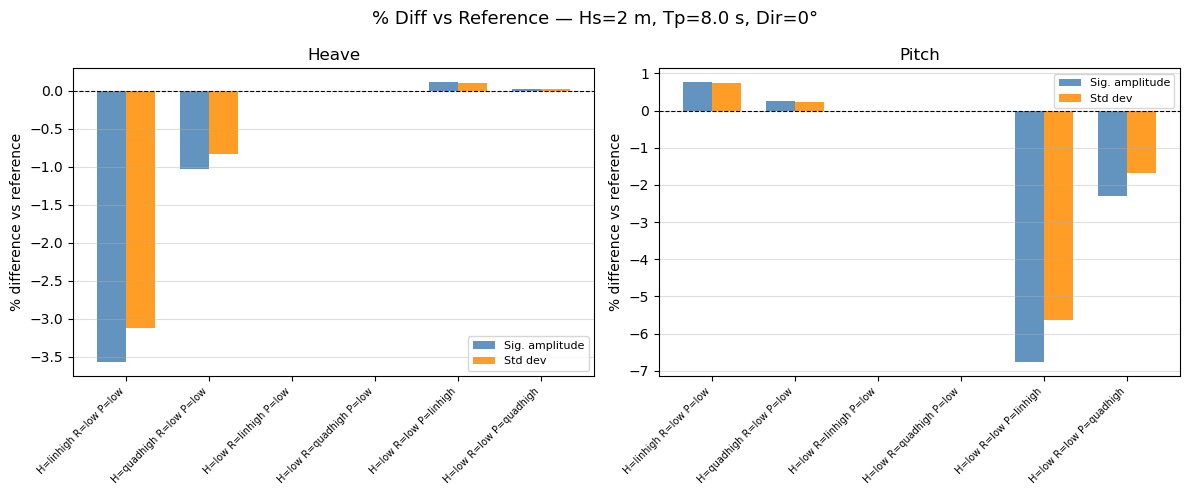

Saved: barchart_Hs2_Tp8.0_dir0.png


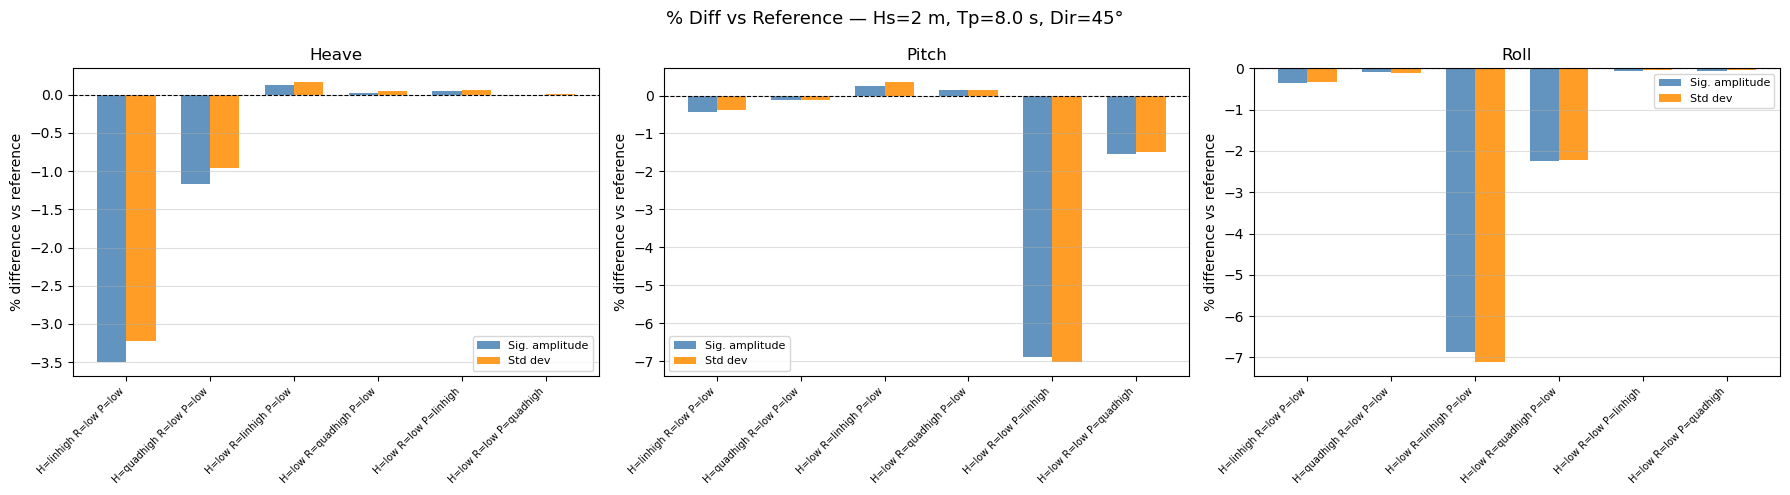

Saved: barchart_Hs2_Tp8.0_dir45.png


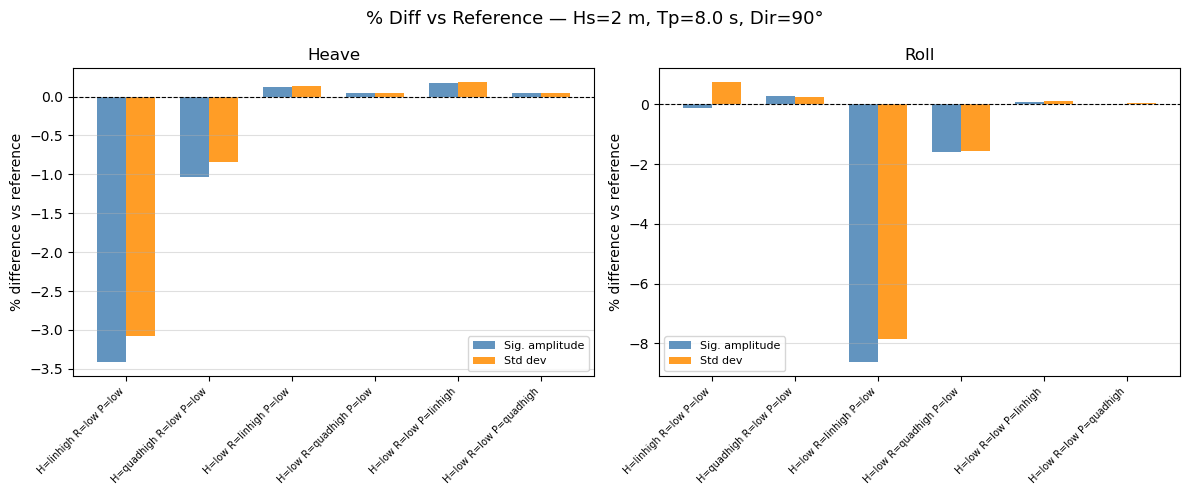

Saved: barchart_Hs2_Tp8.0_dir90.png


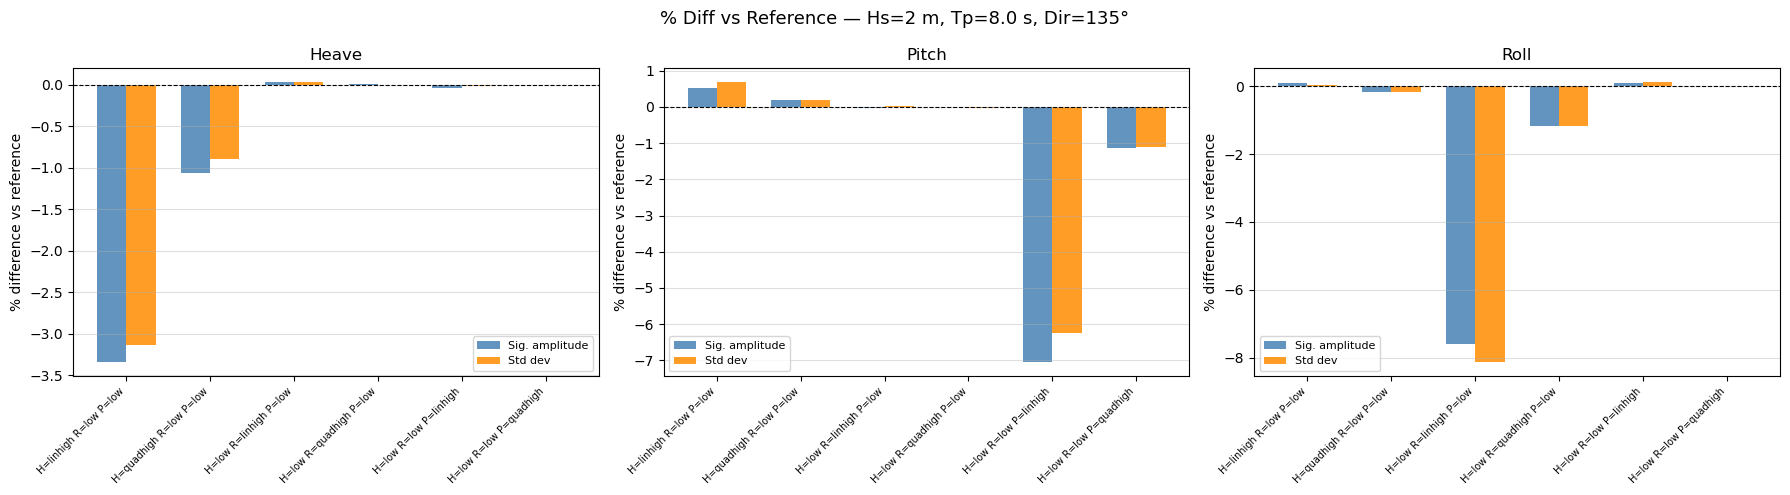

Saved: barchart_Hs2_Tp8.0_dir135.png


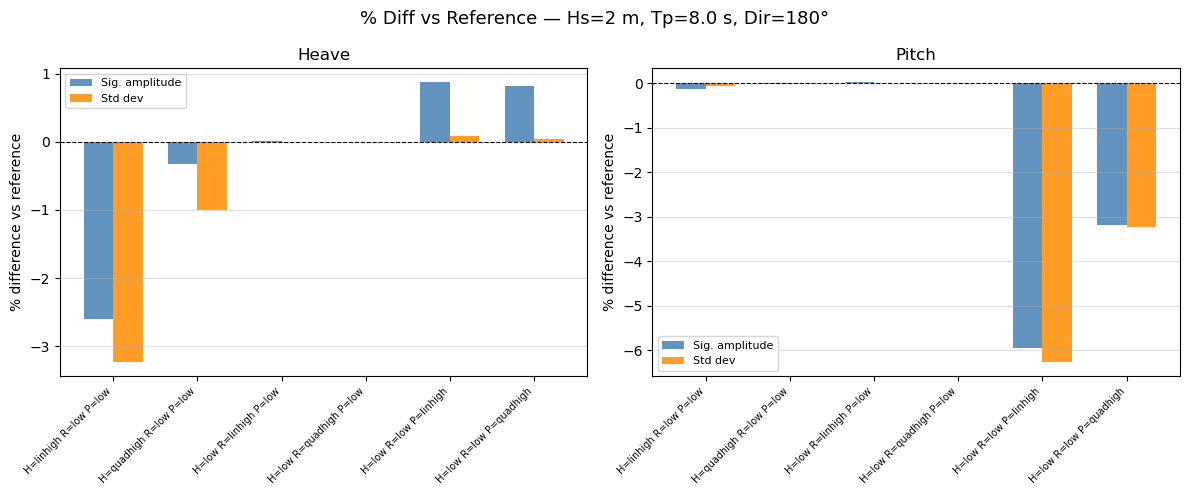

Saved: barchart_Hs2_Tp8.0_dir180.png


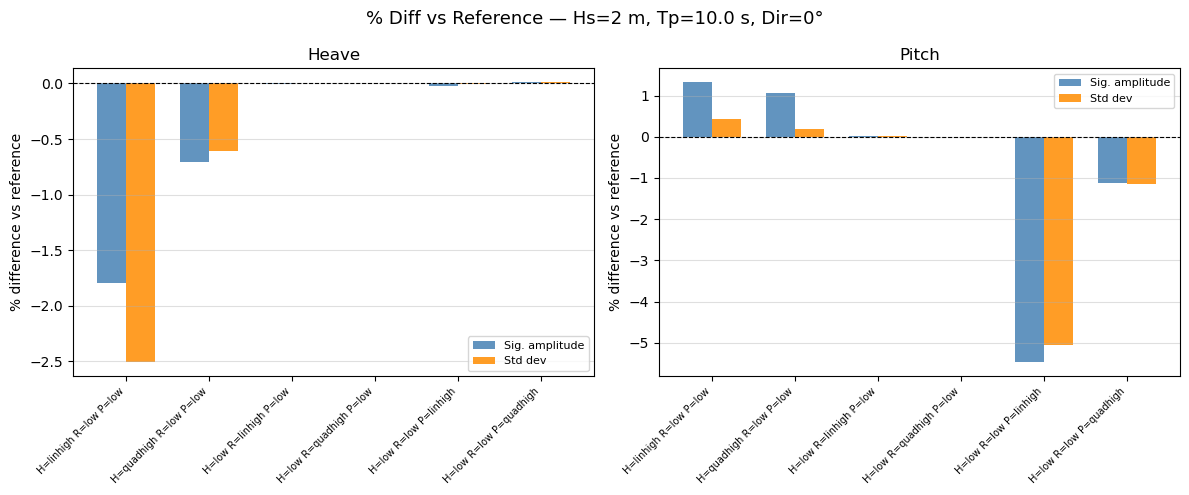

Saved: barchart_Hs2_Tp10.0_dir0.png


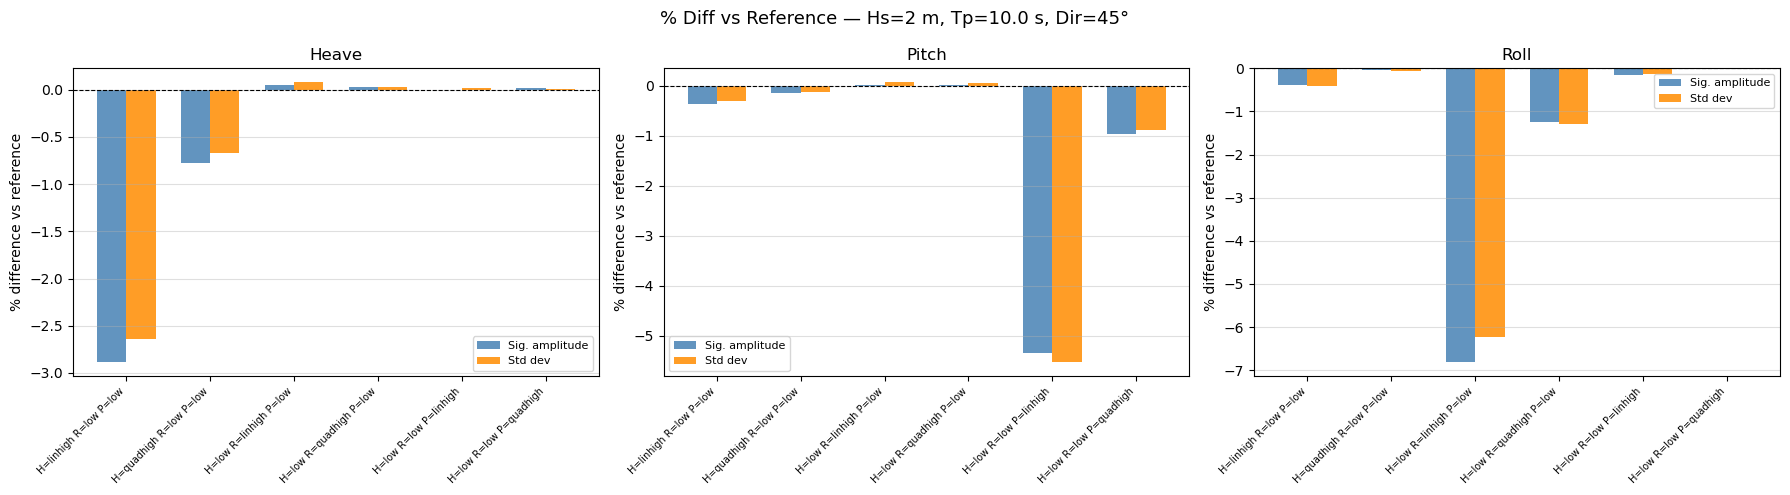

Saved: barchart_Hs2_Tp10.0_dir45.png


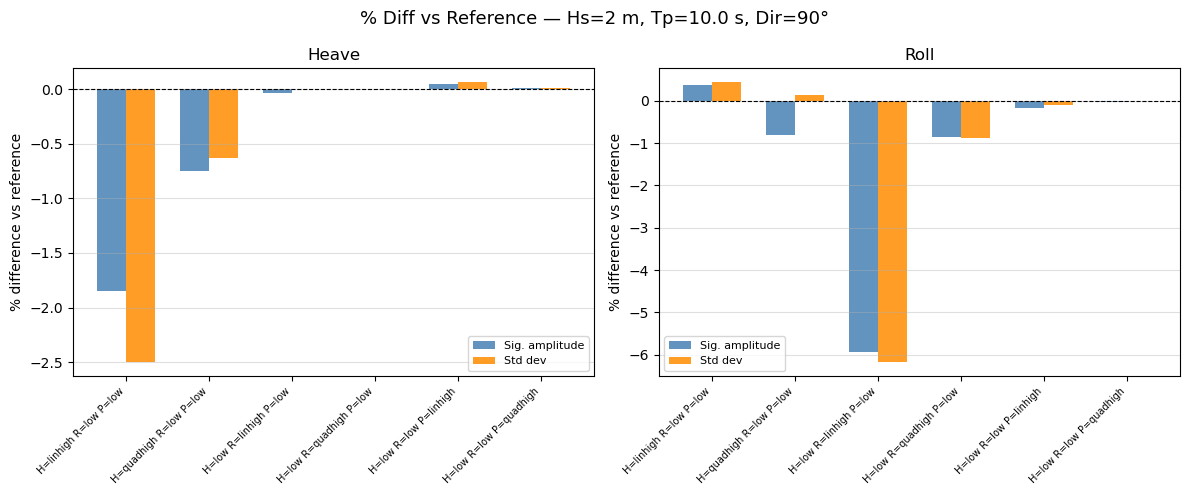

Saved: barchart_Hs2_Tp10.0_dir90.png


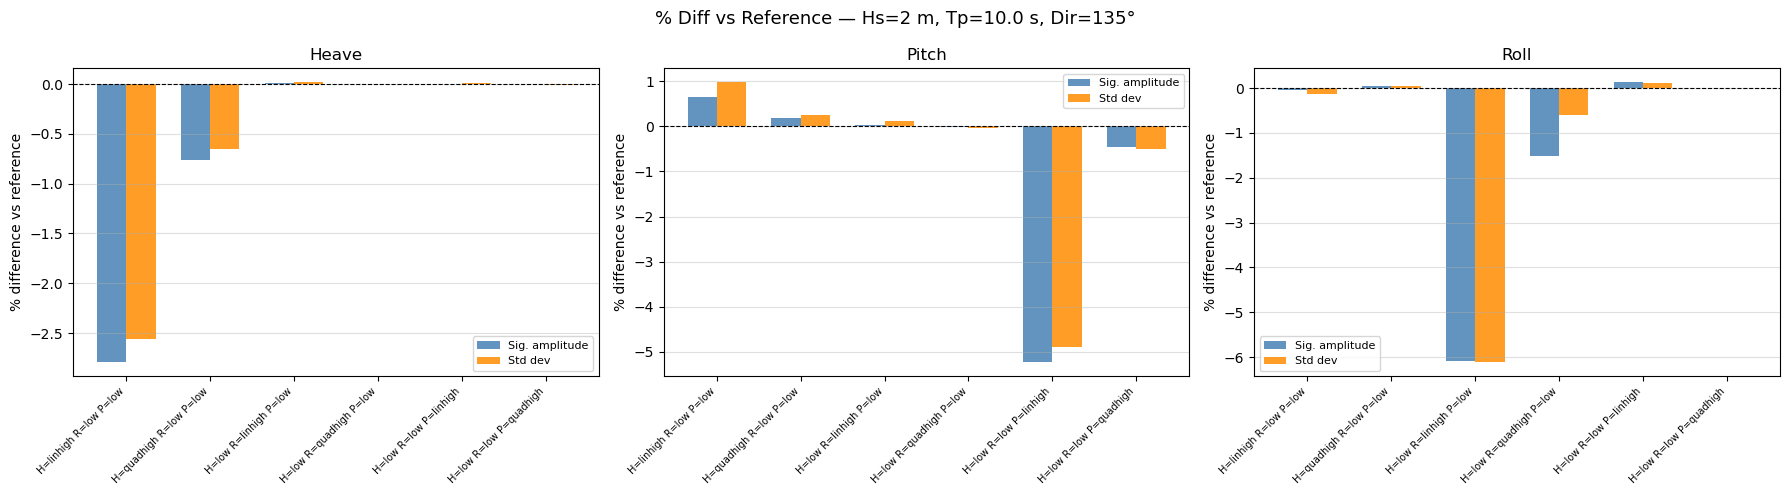

Saved: barchart_Hs2_Tp10.0_dir135.png


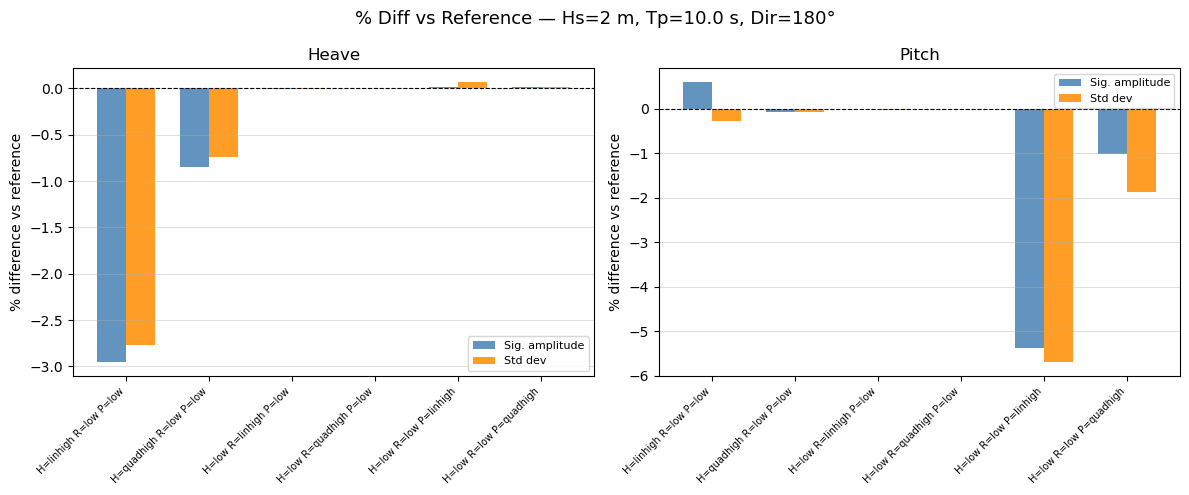

Saved: barchart_Hs2_Tp10.0_dir180.png


In [21]:
# ============================================================
# 10. Bar charts: % difference per seastate + direction
# ============================================================
def damp_label(row):
    return f"H={row['Damp_Heave']} R={row['Damp_Roll']} P={row['Damp_Pitch']}"

non_ref['damp_label'] = non_ref.apply(damp_label, axis=1)

pct_pairs = {
    'heave': ('heave_sig_amp_pct', 'heave_std_pct'),
    'pitch': ('pitch_sig_amp_pct', 'pitch_std_pct'),
    'roll':  ('roll_sig_amp_pct',  'roll_std_pct'),
}

for (hs, tp, direction), group in non_ref.groupby(['Hs', 'Tp', 'Direction']):
    skip = DIR_SKIP_DOF.get(int(direction), [])
    active = {dof: cols for dof, cols in pct_pairs.items() if dof not in skip}
    n      = len(active)

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
    if n == 1: axes = [axes]
    fig.suptitle(f'% Diff vs Reference — Hs={hs} m, Tp={tp} s, Dir={int(direction)}°', fontsize=13)

    for ax, (dof, (sa_col, std_col)) in zip(axes, active.items()):
        labels   = group['damp_label'].values
        sa_vals  = group[sa_col].values
        std_vals = group[std_col].values
        x        = np.arange(len(labels))
        w        = 0.35

        ax.bar(x - w/2, sa_vals,  w, label='Sig. amplitude', color='steelblue',  alpha=0.85)
        ax.bar(x + w/2, std_vals, w, label='Std dev',         color='darkorange', alpha=0.85)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(dof.capitalize())
        ax.set_ylabel('% difference vs reference')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.4)

    plt.tight_layout()
    fname = PLOTS_DIR / f'barchart_Hs{hs}_Tp{tp}_dir{int(direction)}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {fname.name}')

In [22]:
# ============================================================
# 11. Summary — mean |% diff| per varied DOF, per direction
# ============================================================
def which_dof_varied(row):
    varied = []
    if row['Damp_Heave'] != 'low': varied.append('Heave')
    if row['Damp_Roll']  != 'low': varied.append('Roll')
    if row['Damp_Pitch'] != 'low': varied.append('Pitch')
    return '+'.join(varied) if varied else 'Reference'

non_ref['Varied_DOF'] = non_ref.apply(which_dof_varied, axis=1)

all_metric_cols = ['heave_sig_amp_pct', 'pitch_sig_amp_pct', 'roll_sig_amp_pct',
                   'heave_std_pct',     'pitch_std_pct',     'roll_std_pct']

summaries = {}
with pd.ExcelWriter(OUTPUT_DIR / 'sensitivity_summary.xlsx') as writer:
    for direction in sorted(non_ref['Direction'].unique()):
        skip = DIR_SKIP_DOF.get(int(direction), [])
        cols = [c for c in all_metric_cols if not any(s in c for s in skip)]
        sub  = non_ref[non_ref['Direction'] == direction]
        summary = sub.groupby('Varied_DOF')[cols].apply(lambda x: x.abs().mean())
        summary.columns = [c.replace('_pct', '%').replace('_sig_amp', '_sigamp').replace('_', ' ') for c in summary.columns]
        summaries[int(direction)] = summary
        summary.to_excel(writer, sheet_name=f'Direction_{int(direction)}')
        print(f'\nDirection {int(direction)}°:')
        print(summary.round(2).to_string())

print(f'\nSummary saved → {OUTPUT_DIR / "sensitivity_summary.xlsx"}')


Direction 0°:
            heave sigamp%  pitch sigamp%  heave std%  pitch std%
Varied_DOF                                                      
Heave                2.86           0.47        2.70        0.28
Pitch                0.08           3.12        0.07        2.84
Roll                 0.00           0.00        0.00        0.00

Direction 45°:
            heave sigamp%  pitch sigamp%  roll sigamp%  heave std%  pitch std%  roll std%
Varied_DOF                                                                               
Heave                3.02           0.44          0.23        2.88        0.34       0.24
Pitch                0.10           3.28          0.05        0.05        3.28       0.05
Roll                 0.24           0.18          3.57        0.14        0.10       3.58

Direction 90°:
            heave sigamp%  roll sigamp%  heave std%  roll std%
Varied_DOF                                                    
Heave                2.84          0.28        2.81 

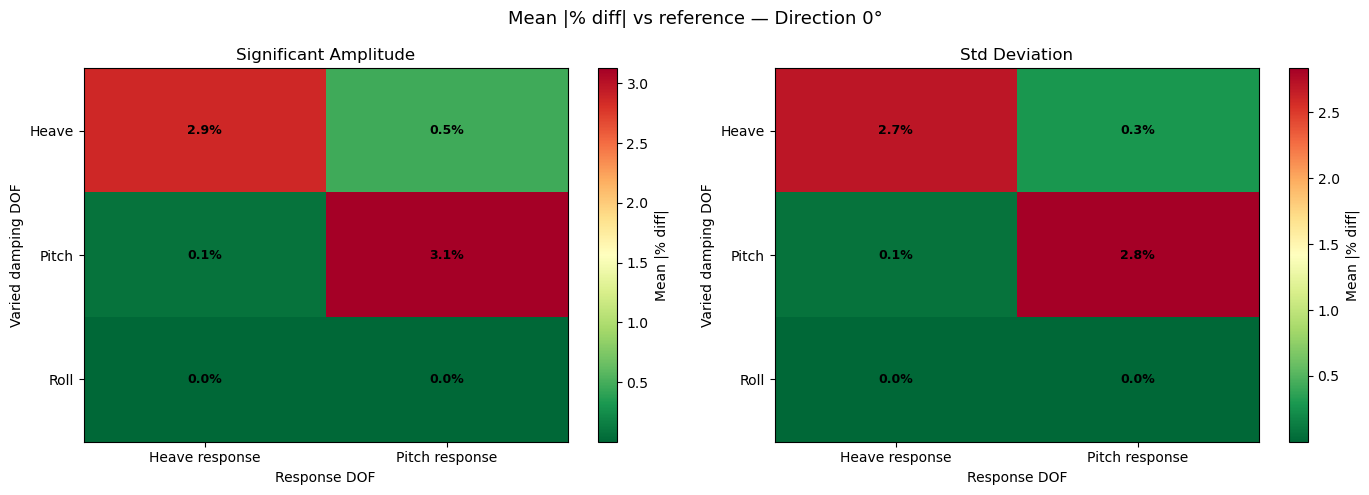

Saved: heatmap_summary_dir0.png


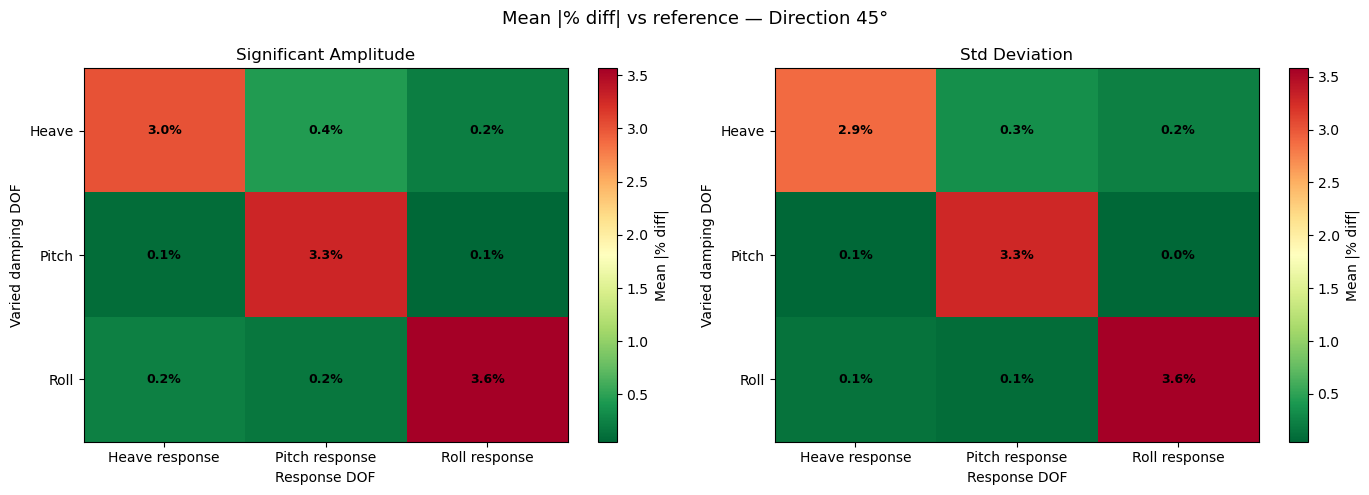

Saved: heatmap_summary_dir45.png


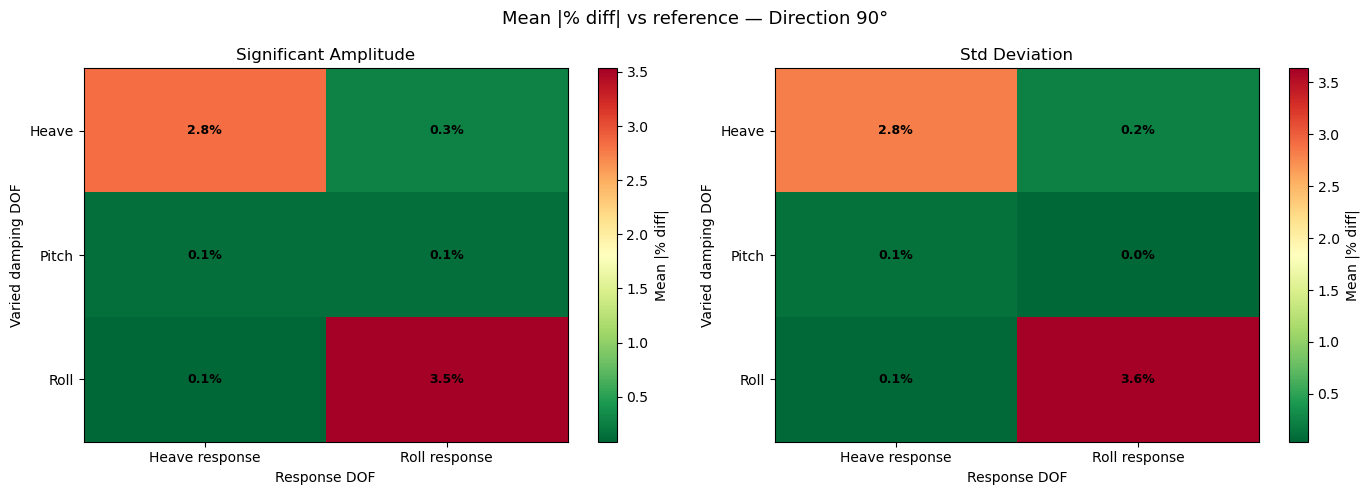

Saved: heatmap_summary_dir90.png


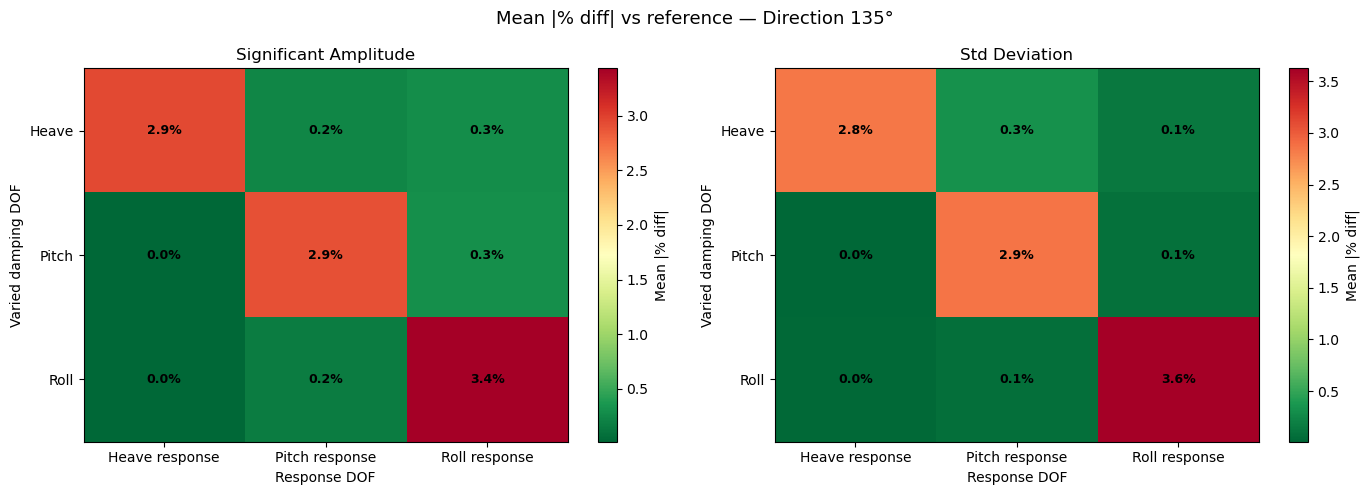

Saved: heatmap_summary_dir135.png


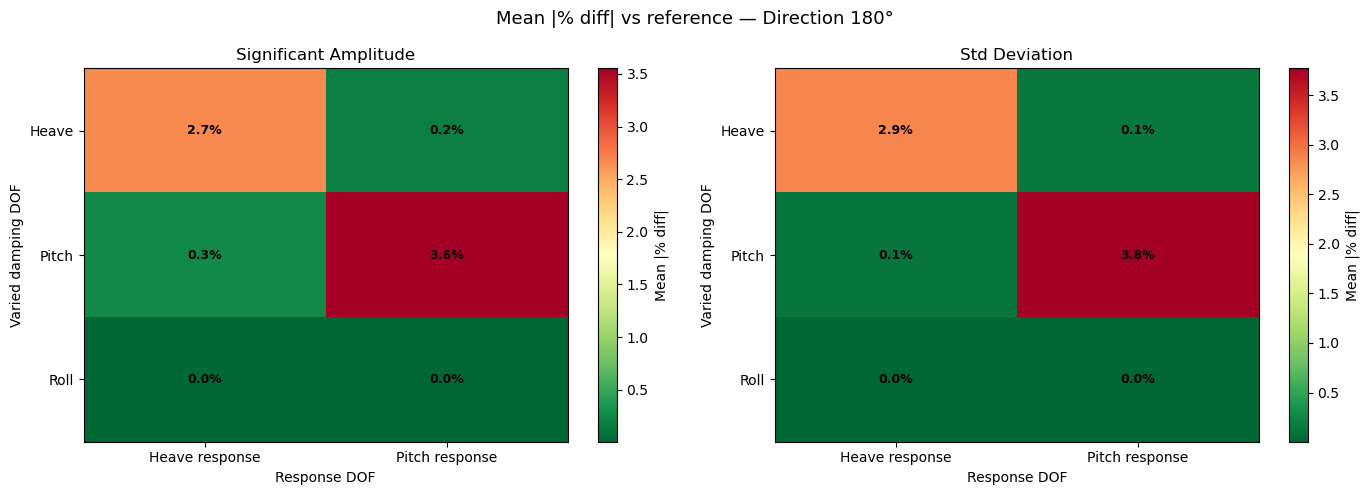

Saved: heatmap_summary_dir180.png


In [23]:
# ============================================================
# 12. Heatmaps per direction
# ============================================================
for direction, summary in summaries.items():
    sa_cols  = [c for c in summary.columns if 'sigamp' in c]
    std_cols = [c for c in summary.columns if 'std'    in c]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Mean |% diff| vs reference — Direction {direction}°', fontsize=13)

    for ax, cols, title in [(axes[0], sa_cols, 'Significant Amplitude'),
                             (axes[1], std_cols, 'Std Deviation')]:
        data = summary[cols].copy()
        # Clean up labels for x-axis
        data.columns = [c.split()[0].capitalize() for c in data.columns]

        im = ax.imshow(data.values, cmap='RdYlGn_r', aspect='auto')
        ax.set_xticks(range(len(data.columns)))
        ax.set_xticklabels([f'{c} response' for c in data.columns])
        ax.set_yticks(range(len(data)))
        ax.set_yticklabels(data.index)
        ax.set_title(title)
        ax.set_xlabel('Response DOF')
        ax.set_ylabel('Varied damping DOF')
        plt.colorbar(im, ax=ax, label='Mean |% diff|')

        for i in range(len(data)):
            for j in range(len(data.columns)):
                ax.text(j, i, f'{data.values[i, j]:.1f}%',
                        ha='center', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    fname = PLOTS_DIR / f'heatmap_summary_dir{direction}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    plt.close()
    print(f'Saved: {fname.name}')

In [35]:
# ============================================================
# 11. Summary — mean |% diff| per varied DOF + type, per direction
# ============================================================
def which_dof_varied(row):
    if row['Damp_Heave'] == 'linhigh':  return 'Heave_linhigh'
    if row['Damp_Heave'] == 'quadhigh': return 'Heave_quadhigh'
    if row['Damp_Roll']  == 'linhigh':  return 'Roll_linhigh'
    if row['Damp_Roll']  == 'quadhigh': return 'Roll_quadhigh'
    if row['Damp_Pitch'] == 'linhigh':  return 'Pitch_linhigh'
    if row['Damp_Pitch'] == 'quadhigh': return 'Pitch_quadhigh'
    return 'Reference'

non_ref['Varied_DOF'] = non_ref.apply(which_dof_varied, axis=1)

all_metric_cols = ['heave_sig_amp_pct', 'pitch_sig_amp_pct', 'roll_sig_amp_pct',
                   'heave_std_pct',     'pitch_std_pct',     'roll_std_pct']

# Fixed row order for heatmap
ROW_ORDER = ['Heave_linhigh', 'Heave_quadhigh',
             'Roll_linhigh',  'Roll_quadhigh',
             'Pitch_linhigh', 'Pitch_quadhigh']

summaries = {}
with pd.ExcelWriter(OUTPUT_DIR / 'sensitivity_summary.xlsx') as writer:
    for direction in sorted(non_ref['Direction'].unique()):
        skip = DIR_SKIP_DOF.get(int(direction), [])
        cols = [c for c in all_metric_cols if not any(s in c for s in skip)]
        sub  = non_ref[non_ref['Direction'] == direction]
        summary = sub.groupby('Varied_DOF')[cols].apply(lambda x: x.abs().mean())
        # Reorder rows, keep only rows that exist
        summary = summary.reindex([r for r in ROW_ORDER if r in summary.index])
        summary.columns = [c.replace('_pct', '%').replace('_sig_amp', '_sigamp').replace('_', ' ')
                           for c in summary.columns]
        summaries[int(direction)] = summary
        summary.to_excel(writer, sheet_name=f'Direction_{int(direction)}')
        print(f'\nDirection {int(direction)}°:')
        print(summary.round(2).to_string())

print(f'\nSummary saved → {OUTPUT_DIR / "sensitivity_summary.xlsx"}')


Direction 0°:
                heave sigamp%  pitch sigamp%  heave std%  pitch std%
Varied_DOF                                                          
Heave_linhigh            4.61           0.61        4.43        0.41
Heave_quadhigh           1.11           0.33        0.97        0.14
Roll_linhigh             0.00           0.00        0.00        0.00
Roll_quadhigh            0.00           0.00        0.00        0.00
Pitch_linhigh            0.11           4.59        0.10        4.27
Pitch_quadhigh           0.05           1.66        0.03        1.40

Direction 45°:
                heave sigamp%  pitch sigamp%  roll sigamp%  heave std%  pitch std%  roll std%
Varied_DOF                                                                                   
Heave_linhigh            4.81           0.58          0.38        4.68        0.50       0.39
Heave_quadhigh           1.22           0.30          0.07        1.08        0.18       0.08
Roll_linhigh             0.31           0

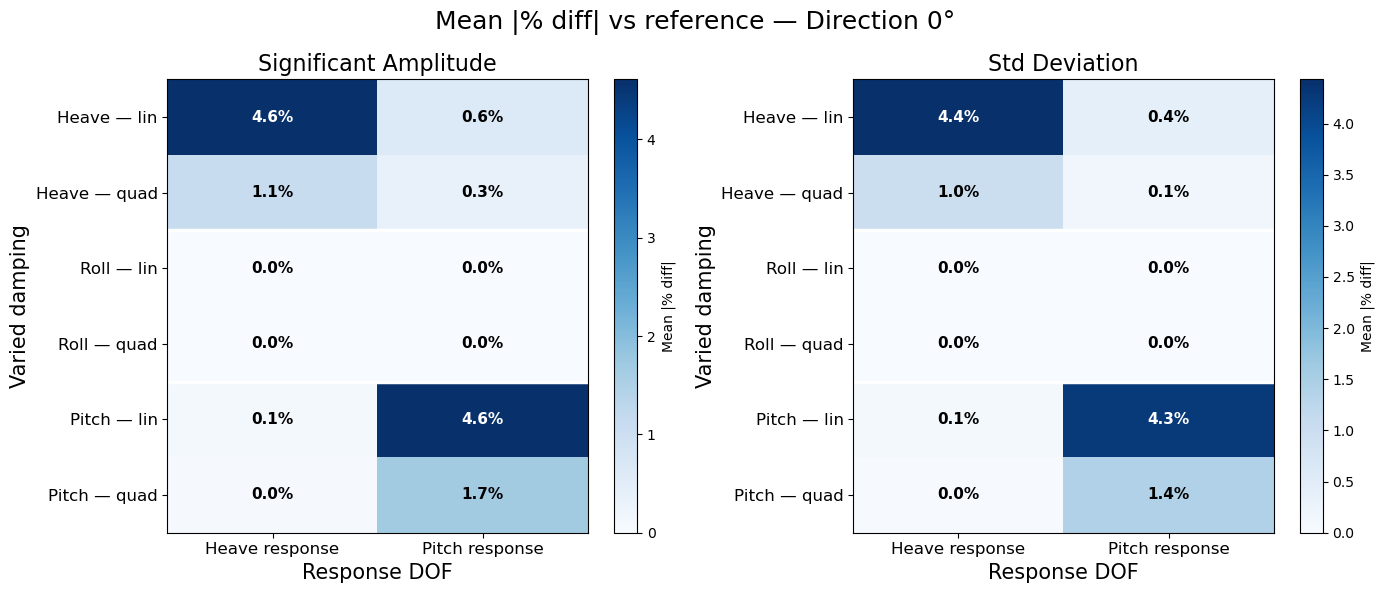

Saved: heatmap_summary_dir0.png


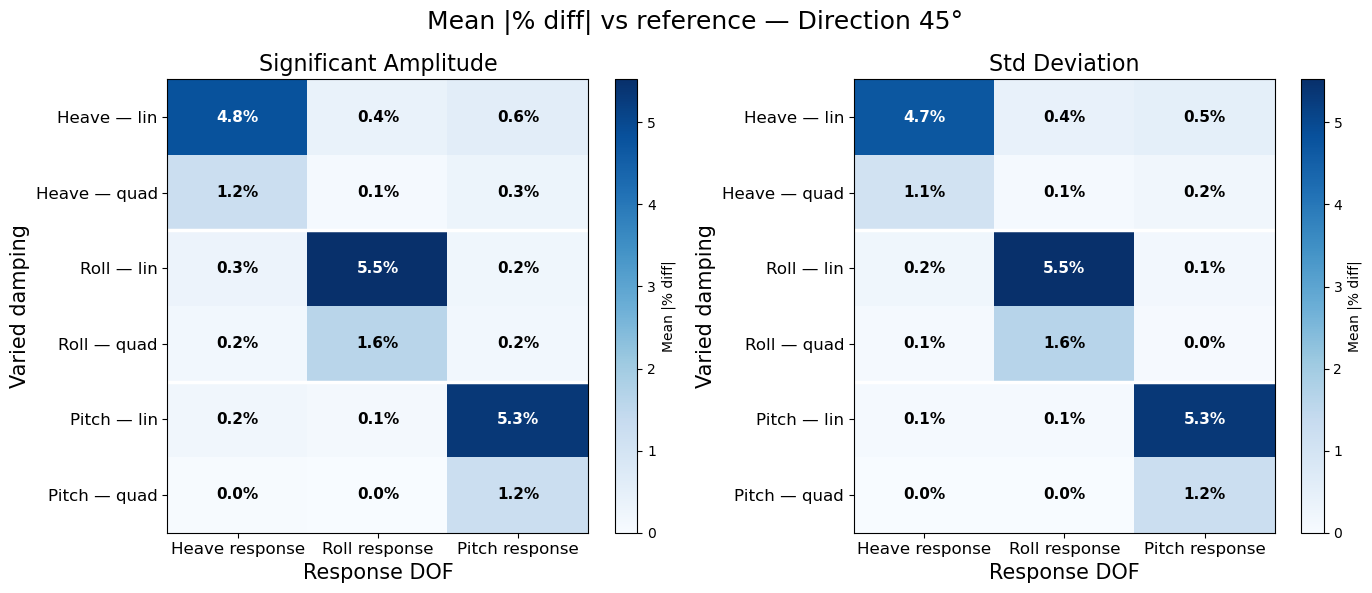

Saved: heatmap_summary_dir45.png


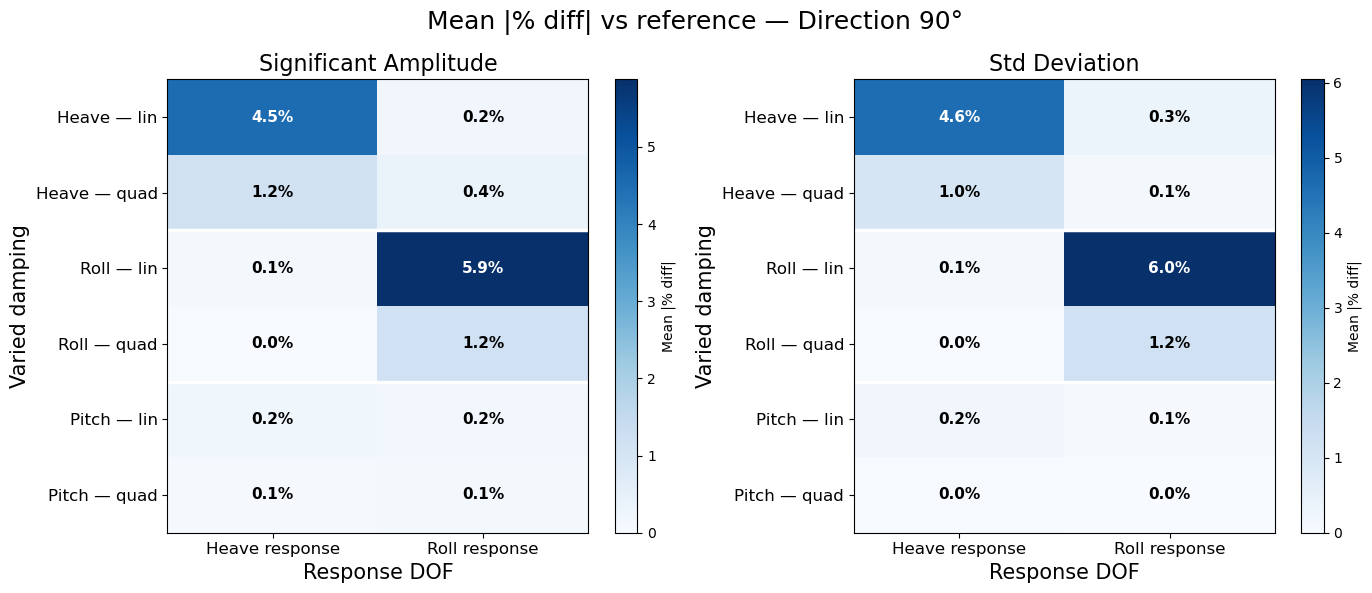

Saved: heatmap_summary_dir90.png


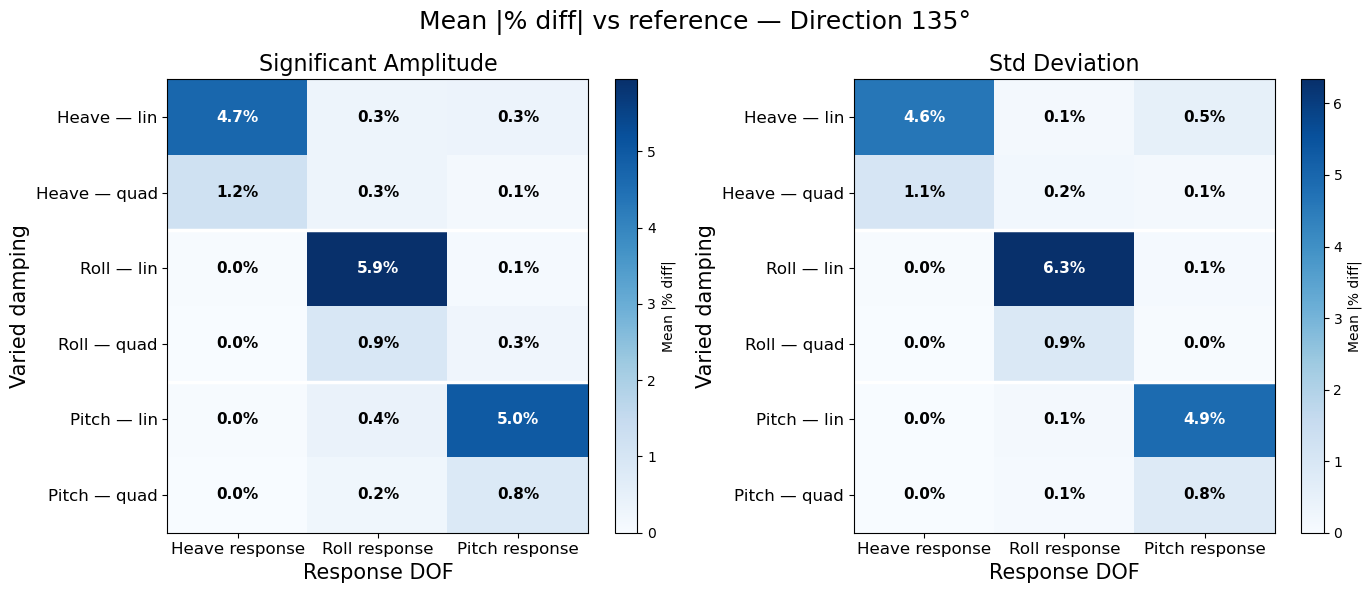

Saved: heatmap_summary_dir135.png


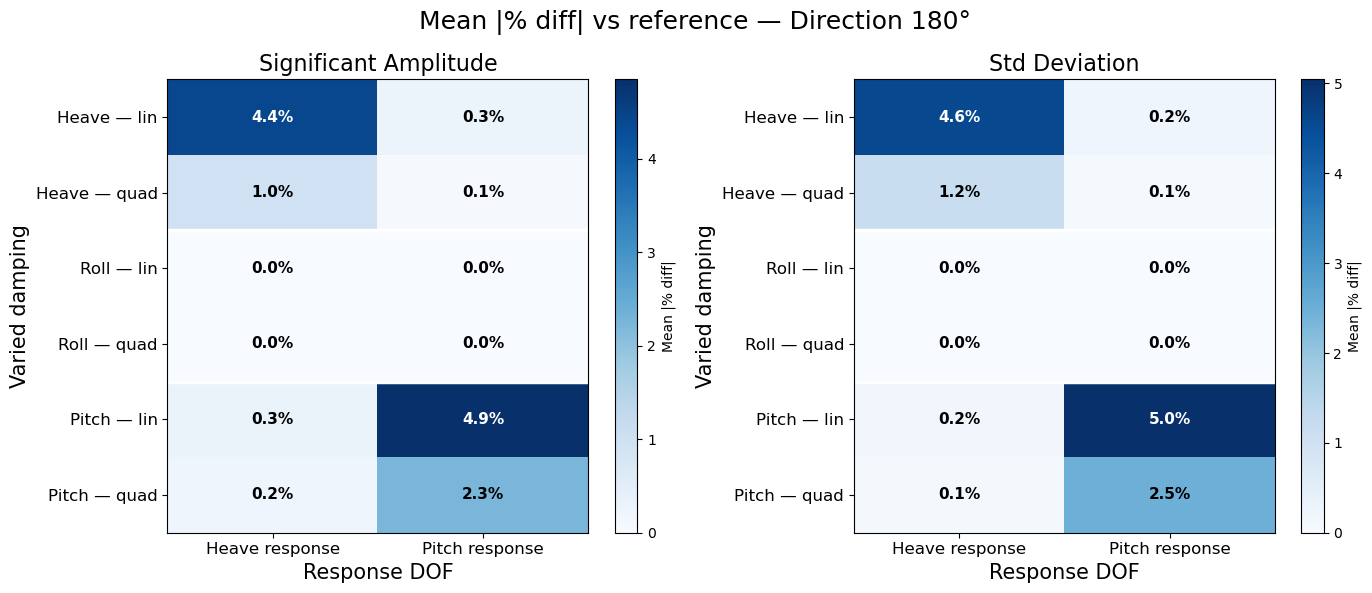

Saved: heatmap_summary_dir180.png


In [ ]:
# ============================================================
# 12. Heatmaps per direction — rows = lin/quad per DOF
# ============================================================

ROW_LABELS = {
    'Heave_linhigh':  'Heave — lin',
    'Heave_quadhigh': 'Heave — quad',
    'Pitch_linhigh':  'Pitch — lin',
    'Pitch_quadhigh': 'Pitch — quad',
    'Roll_linhigh':   'Roll — lin',
    'Roll_quadhigh':  'Roll — quad',
}

# Fixed column order: Heave, Pitch, Roll
COL_ORDER_SA  = ['heave sigamp%', 'pitch sigamp%', 'roll sigamp%']
COL_ORDER_STD = ['heave std%',    'pitch std%',    'roll std%']

# Fixed row order
ROW_ORDER = ['Heave_linhigh', 'Heave_quadhigh',
             'Pitch_linhigh', 'Pitch_quadhigh',
             'Roll_linhigh',  'Roll_quadhigh']

for direction, summary in summaries.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Mean |% diff| vs reference — Direction {direction}°', fontsize=TITLE_SIZE)

    for ax, col_order, title in [
        (axes[0], COL_ORDER_SA,  'Significant Amplitude'),
        (axes[1], COL_ORDER_STD, 'Std Deviation'),
    ]:
        # Select and reorder columns + rows
        available_cols = [c for c in col_order if c in summary.columns]
        available_rows = [r for r in ROW_ORDER if r in summary.index]
        data = summary.loc[available_rows, available_cols].copy()

        # Clean axis labels
        x_labels = [c.split()[0].capitalize() + ' response' for c in data.columns]
        y_labels  = [ROW_LABELS.get(r, r) for r in data.index]

        im = ax.imshow(data.values, cmap='Blues', aspect='auto',
                       vmin=0, vmax=max(data.values.max(), 1))
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, fontsize=TICK_SIZE - 1)
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=TICK_SIZE - 1)
        ax.set_title(title, fontsize=TITLE_SIZE - 2)
        ax.set_xlabel('Response DOF', fontsize=LABEL_SIZE)
        ax.set_ylabel('Varied damping', fontsize=LABEL_SIZE)
        plt.colorbar(im, ax=ax, label='Mean |% diff|')

        # Value labels
        for i in range(len(data)):
            for j in range(len(data.columns)):
                val = data.values[i, j]
                ax.text(j, i, f'{val:.1f}%',
                        ha='center', va='center', fontsize=TICK_SIZE - 2,
                        fontweight='bold',
                        color='white' if val > data.values.max() * 0.6 else 'black')

        # Separators between DOF groups
        for sep in [1.5, 3.5]:
            ax.axhline(sep, color='white', linewidth=2.5)

    plt.tight_layout()
    fname = PLOTS_DIR / f'heatmap_summary_dir{direction}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {fname.name}')

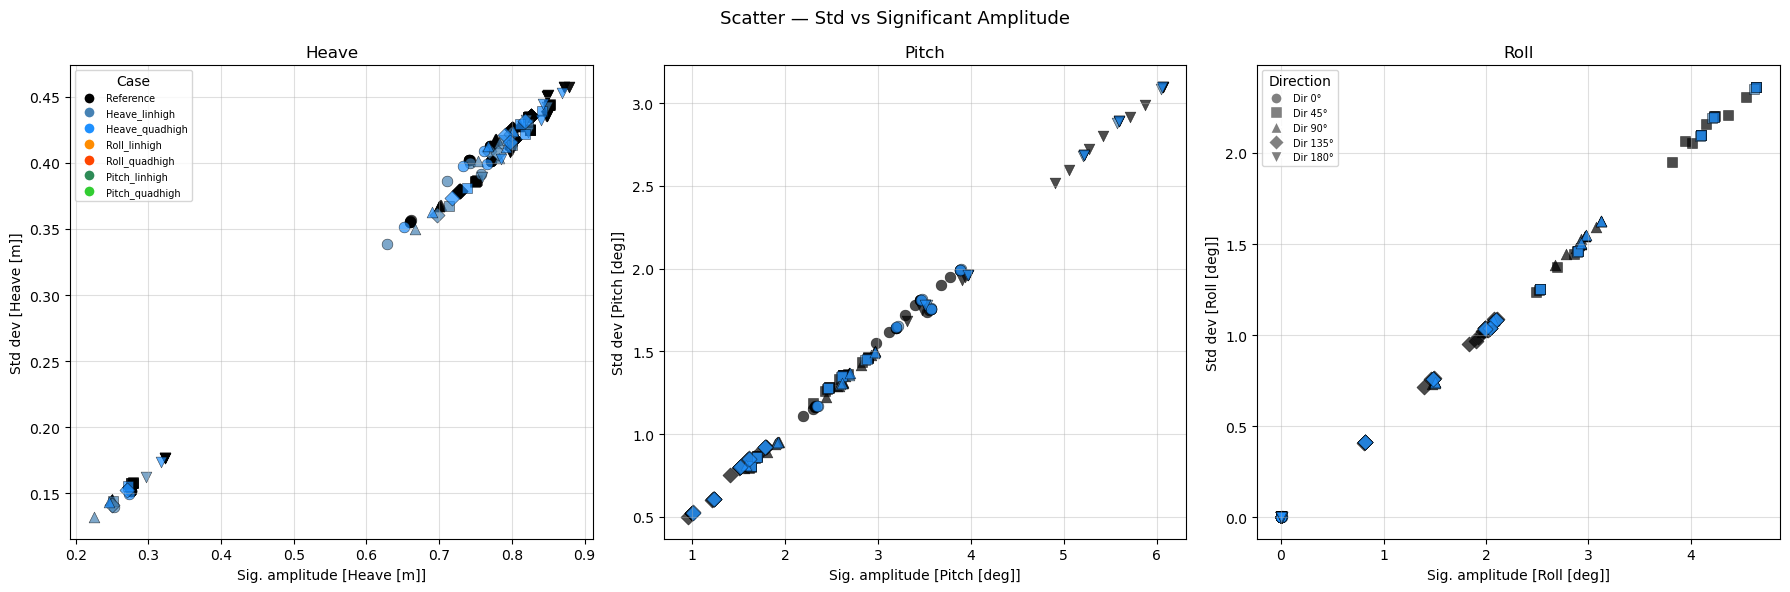

Saved: scatter_std_vs_sigamp.png


In [24]:
# ============================================================
# 13. Scatter — σ vs Sig. amplitude per DOF
#     Color per damping case type, marker shape per direction
# ============================================================
results['case_type'] = results.apply(case_type, axis=1)

case_color = {
    'Reference':       'black',
    'Heave_linhigh':   'steelblue',
    'Heave_quadhigh':  'dodgerblue',
    'Roll_linhigh':    'darkorange',
    'Roll_quadhigh':   'orangered',
    'Pitch_linhigh':   'seagreen',
    'Pitch_quadhigh':  'limegreen',
}
dir_marker = {0: 'o', 45: 's', 90: '^', 135: 'D', 180: 'v'}

dof_scatter = {
    'heave': ('heave_sig_amp', 'heave_std', 'Heave [m]'),
    'pitch': ('pitch_sig_amp', 'pitch_std', 'Pitch [deg]'),
    'roll':  ('roll_sig_amp',  'roll_std',  'Roll [deg]'),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Scatter — Std vs Significant Amplitude', fontsize=13)

for ax, (dof, (sa_col, std_col, lbl)) in zip(axes, dof_scatter.items()):
    for ctype, color in case_color.items():
        for direction, marker in dir_marker.items():
            sel = results[(results['case_type'] == ctype) & (results['Direction'] == direction)]
            if len(sel) == 0:
                continue
            ax.scatter(sel[sa_col], sel[std_col],
                       c=color, marker=marker, s=60, alpha=0.7,
                       edgecolors='black', linewidth=0.4)

    ax.set_xlabel(f'Sig. amplitude [{lbl}]')
    ax.set_ylabel(f'Std dev [{lbl}]')
    ax.set_title(dof.capitalize())
    ax.grid(True, alpha=0.4)

# Build combined legend
from matplotlib.lines import Line2D
legend_color = [Line2D([0], [0], marker='o', color='w', label=c,
                       markerfacecolor=col, markersize=8)
                for c, col in case_color.items()]
legend_marker = [Line2D([0], [0], marker=m, color='w', label=f'Dir {d}°',
                        markerfacecolor='gray', markersize=8)
                 for d, m in dir_marker.items()]

axes[0].legend(handles=legend_color, fontsize=7, title='Case', loc='upper left')
axes[-1].legend(handles=legend_marker, fontsize=7, title='Direction', loc='upper left')

plt.tight_layout()
fname = PLOTS_DIR / 'scatter_std_vs_sigamp.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved: {fname.name}')

In [25]:
# ============================================================
# 14. Ranking of damping cases per DOF (sig amp + std)
# ============================================================
rank_cols = ['filename', 'Hs', 'Tp', 'Direction', 'Damp_Heave', 'Damp_Roll', 'Damp_Pitch',
             'heave_sig_amp', 'heave_std', 'pitch_sig_amp', 'pitch_std', 'roll_sig_amp', 'roll_std']

with pd.ExcelWriter(OUTPUT_DIR / 'sensitivity_ranking.xlsx') as writer:
    for dof in ['heave', 'pitch', 'roll']:
        sa_col  = f'{dof}_sig_amp'
        std_col = f'{dof}_std'

        ranked = results[rank_cols].copy()
        ranked = ranked.sort_values(by=sa_col, ascending=True).reset_index(drop=True)
        ranked.insert(0, f'rank_{dof}_sigamp', range(1, len(ranked) + 1))
        ranked.to_excel(writer, sheet_name=f'{dof}_by_sigamp', index=False)

        ranked2 = results[rank_cols].copy()
        ranked2 = ranked2.sort_values(by=std_col, ascending=True).reset_index(drop=True)
        ranked2.insert(0, f'rank_{dof}_std', range(1, len(ranked2) + 1))
        ranked2.to_excel(writer, sheet_name=f'{dof}_by_std', index=False)

print(f'Saved → {OUTPUT_DIR / "sensitivity_ranking.xlsx"}')
print('\nLowest sig amp cases per DOF (top 5):')
for dof in ['heave', 'pitch', 'roll']:
    sa_col = f'{dof}_sig_amp'
    print(f'\n--- {dof.upper()} ---')
    cols_show = ['Hs', 'Tp', 'Direction', 'Damp_Heave', 'Damp_Roll', 'Damp_Pitch', sa_col]
    print(results[cols_show].sort_values(sa_col).head(5).to_string(index=False))

Saved → C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Simulaties_sensitvities1_2\analysis\sensitivity_ranking.xlsx

Lowest sig amp cases per DOF (top 5):

--- HEAVE ---
 Hs   Tp  Direction Damp_Heave Damp_Roll Damp_Pitch  heave_sig_amp
  2 4.08         90    linhigh       low        low       0.225200
  2 4.08         90   quadhigh       low        low       0.245473
  2 4.08         90        low       low        low       0.249007
  2 4.08         90        low  quadhigh        low       0.249233
  2 4.08         90        low       low   quadhigh       0.249303

--- PITCH ---
 Hs   Tp  Direction Damp_Heave Damp_Roll Damp_Pitch  pitch_sig_amp
  2 10.0        135        low       low    linhigh       0.950955
  2 10.0        135        low       low   quadhigh       0.998839
  2 10.0        135        low  quadhigh        low       1.003320
  2 10.0        135        low       low        low       1.003420
  2 10.0        135        low   linhigh        low       1.0036

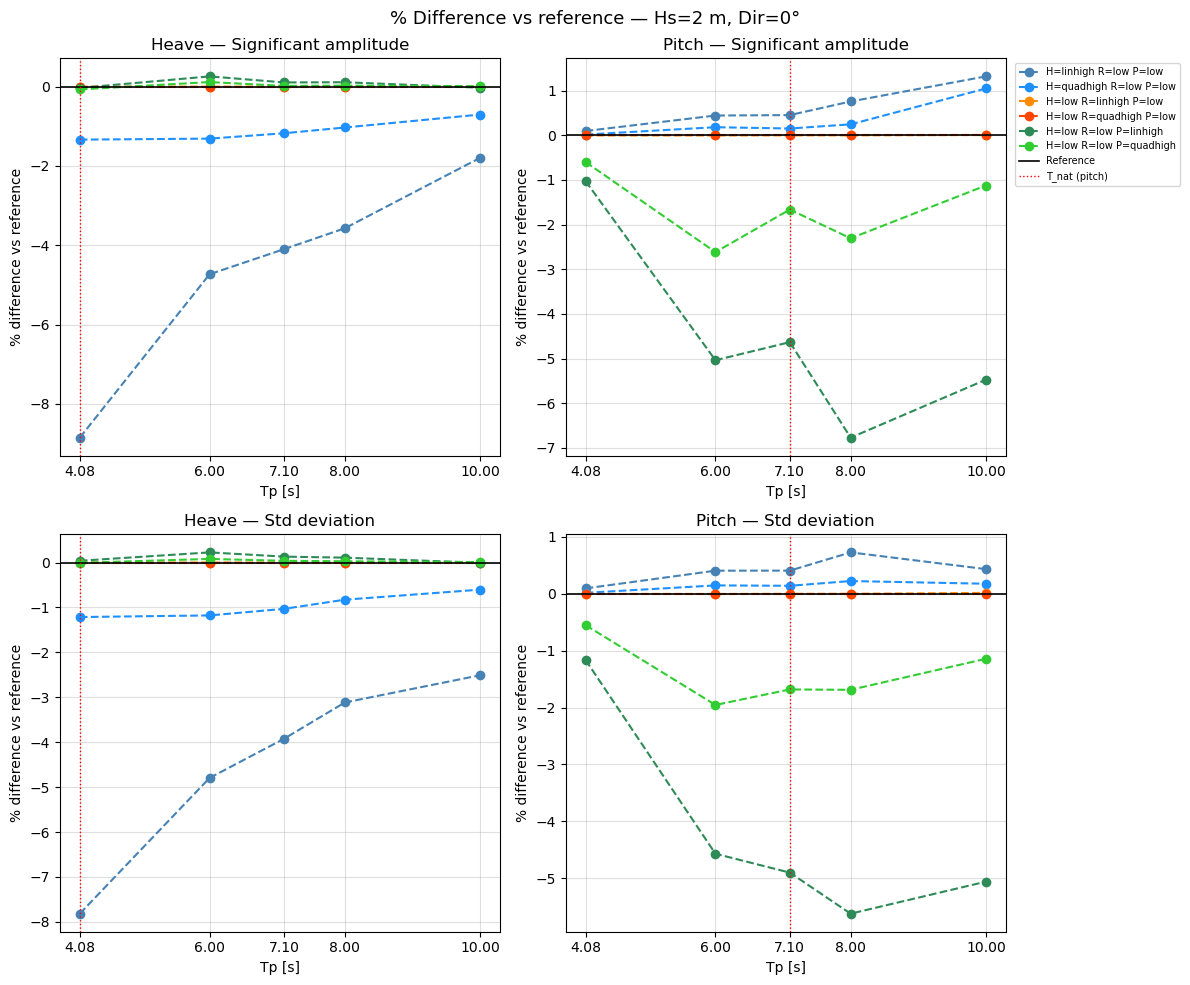

Saved: pct_vs_Tp_Hs2_dir0.png


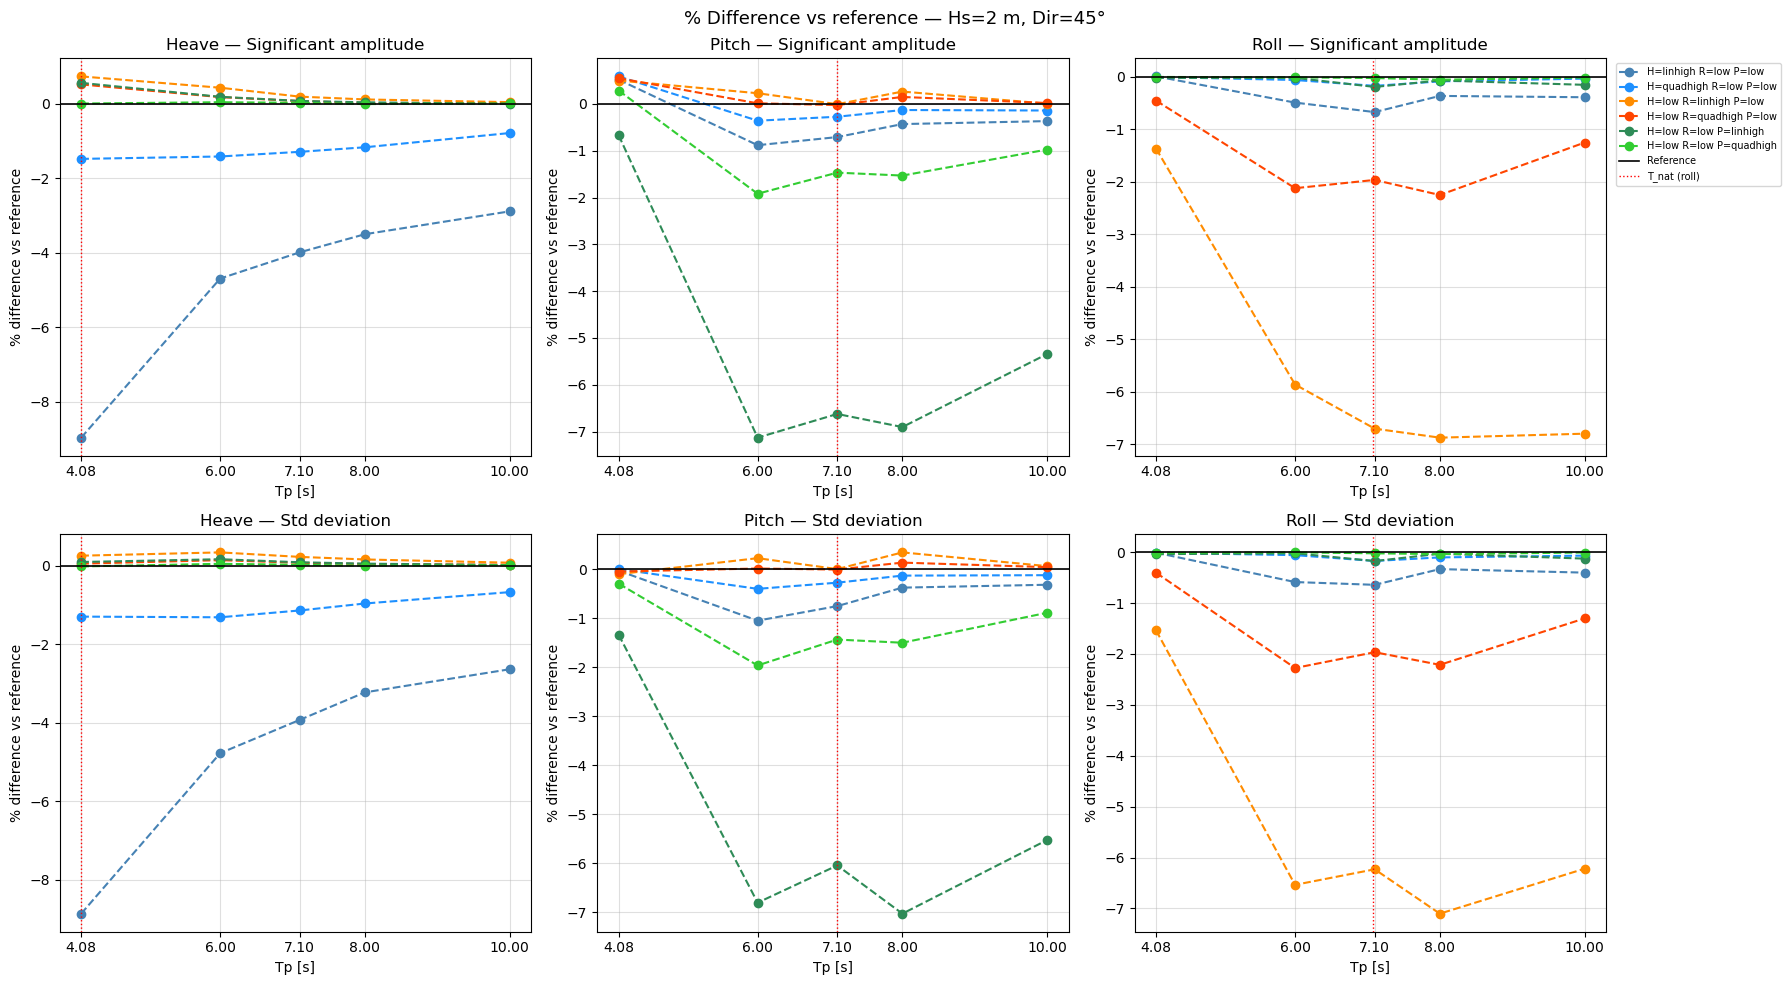

Saved: pct_vs_Tp_Hs2_dir45.png


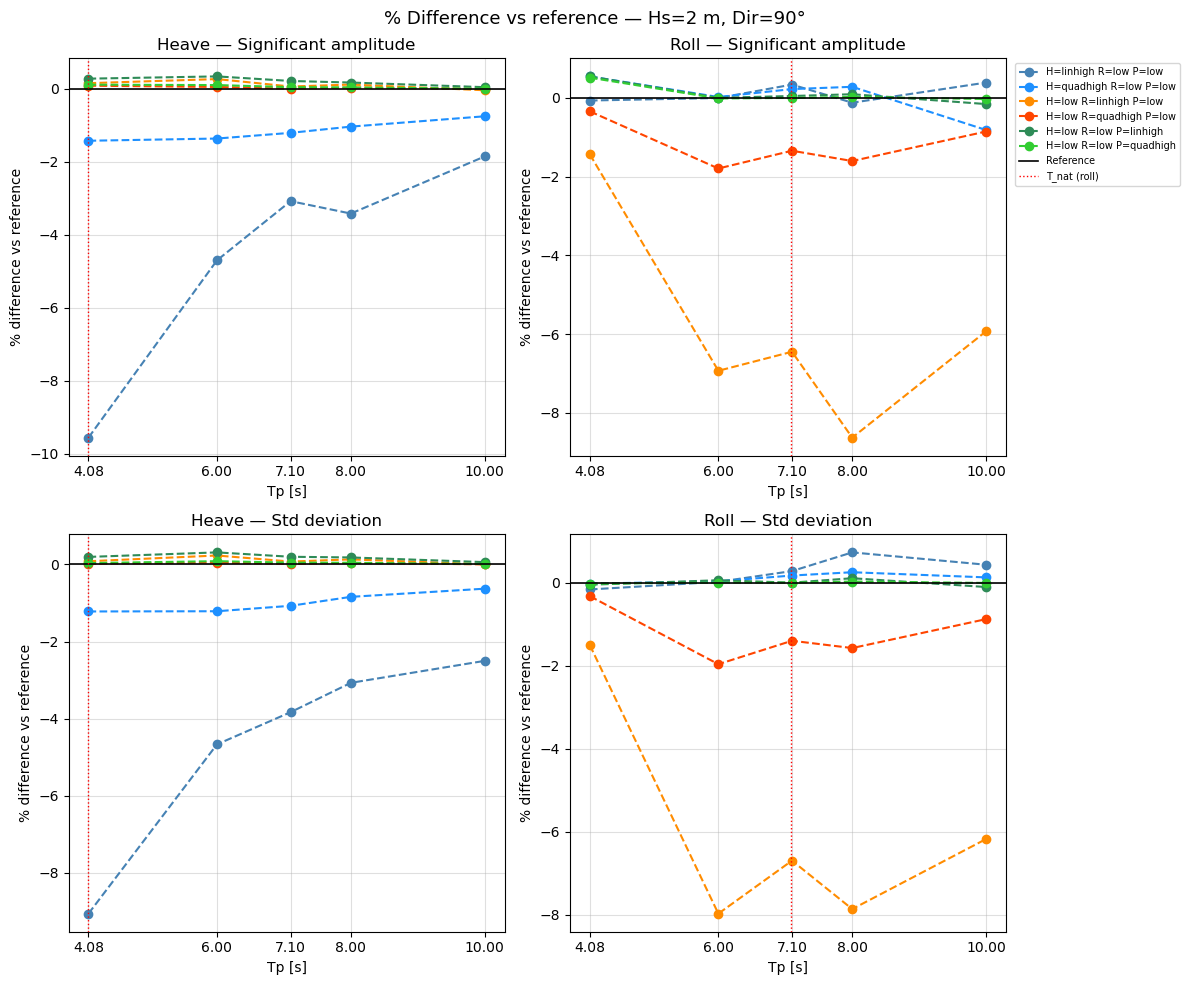

Saved: pct_vs_Tp_Hs2_dir90.png


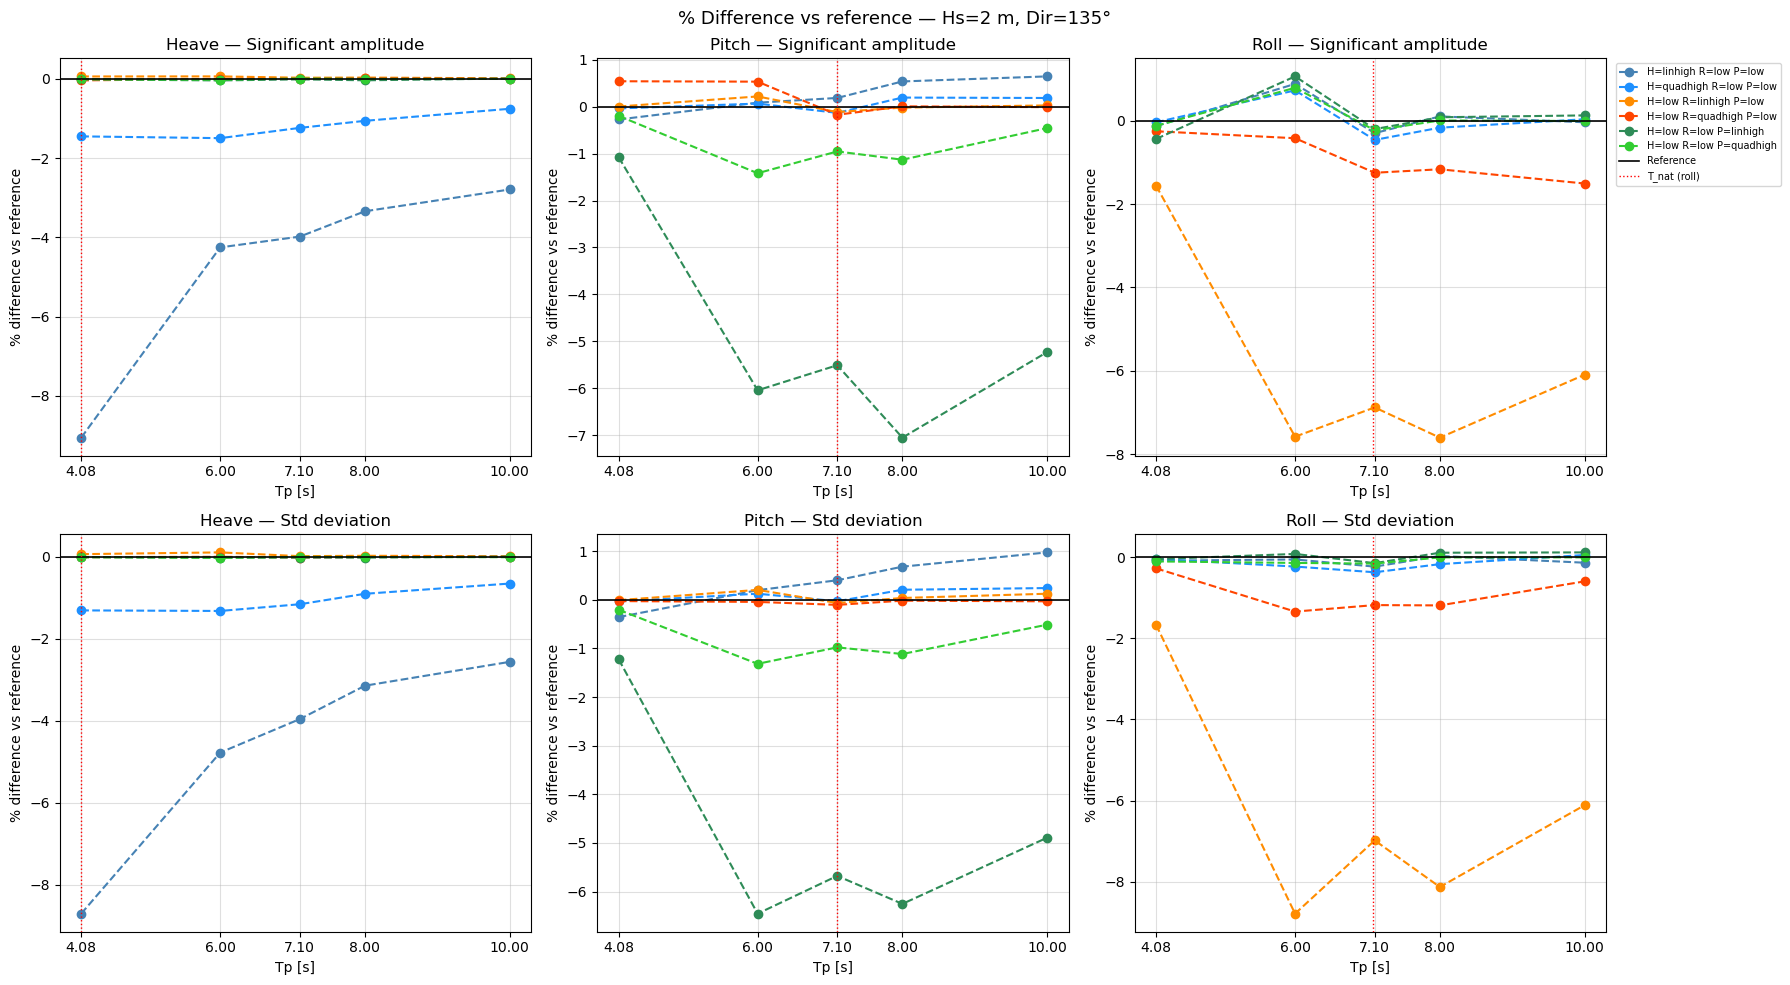

Saved: pct_vs_Tp_Hs2_dir135.png


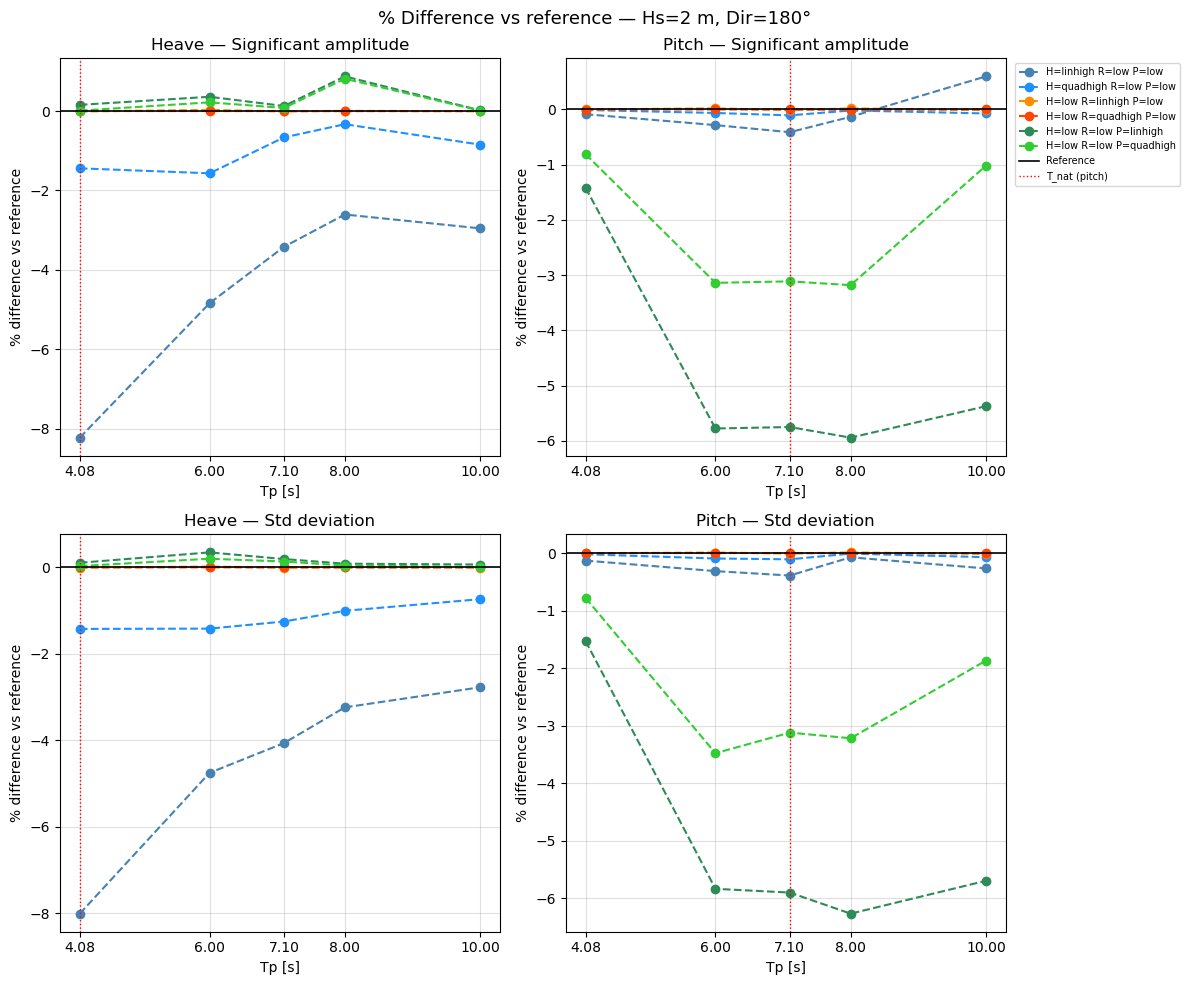

Saved: pct_vs_Tp_Hs2_dir180.png


In [26]:
# ============================================================
# 15. % difference vs Tp — one line per damping case
#     Per Hs, per direction
#     Vertical red dashed line at natural period per DOF
# ============================================================
dof_pct_pairs = {
    'heave': ('heave_sig_amp_pct', 'heave_std_pct'),
    'pitch': ('pitch_sig_amp_pct', 'pitch_std_pct'),
    'roll':  ('roll_sig_amp_pct',  'roll_std_pct'),
}

damp_colors = ['steelblue', 'dodgerblue', 'darkorange', 'orangered', 'seagreen', 'limegreen']

for direction in sorted(results['Direction'].unique()):
    skip = DIR_SKIP_DOF.get(int(direction), [])
    active = {dof: cols for dof, cols in dof_pct_pairs.items() if dof not in skip}
    n = len(active)

    for hs in sorted(results['Hs'].unique()):
        sub = non_ref[(non_ref['Direction'] == direction) & (non_ref['Hs'] == hs)].copy()
        if len(sub) == 0: continue
        sub['damp_label'] = sub.apply(damp_label, axis=1)
        damp_cases = sub['damp_label'].unique()
        tp_vals    = sorted(sub['Tp'].unique())

        fig, axes = plt.subplots(2, n, figsize=(6 * n, 10), sharey=False)
        if n == 1: axes = axes.reshape(2, 1)
        fig.suptitle(f'% Difference vs reference — Hs={hs} m, Dir={int(direction)}°', fontsize=13)

        for col_i, (dof, (sa_col, std_col)) in enumerate(active.items()):
            for row_i, (metric_col, metric_lbl) in enumerate([
                (sa_col,  'Significant amplitude'),
                (std_col, 'Std deviation'),
            ]):
                ax = axes[row_i][col_i]
                for c_i, damp_case in enumerate(damp_cases):
                    grp = sub[sub['damp_label'] == damp_case].sort_values('Tp')
                    ax.plot(grp['Tp'], grp[metric_col],
                            marker='o', linewidth=1.5, linestyle='--',
                            color=damp_colors[c_i % len(damp_colors)],
                            label=damp_case)

                ax.axhline(0, color='black', linewidth=1.2, label='Reference')
                if dof in NAT_PERIODS:
                    ax.axvline(NAT_PERIODS[dof], color='red', linewidth=1.0, linestyle=':',
                               label=f'T_nat ({dof})')

                ax.set_title(f'{dof.capitalize()} — {metric_lbl}')
                ax.set_xlabel('Tp [s]')
                ax.set_ylabel('% difference vs reference')
                ax.set_xticks(tp_vals)
                ax.grid(True, alpha=0.4)
                if col_i == n - 1 and row_i == 0:
                    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

        plt.tight_layout()
        fname = PLOTS_DIR / f'pct_vs_Tp_Hs{hs}_dir{int(direction)}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f'Saved: {fname.name}')

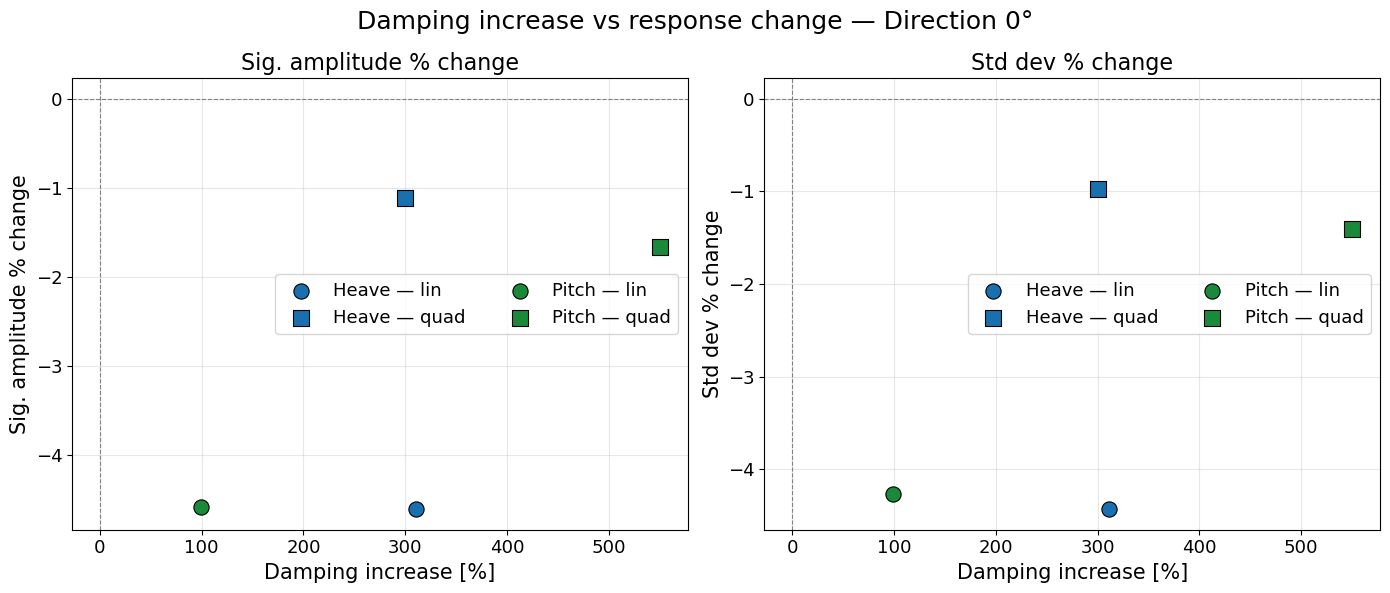

Saved: damp_vs_response_scatter_dir0.png


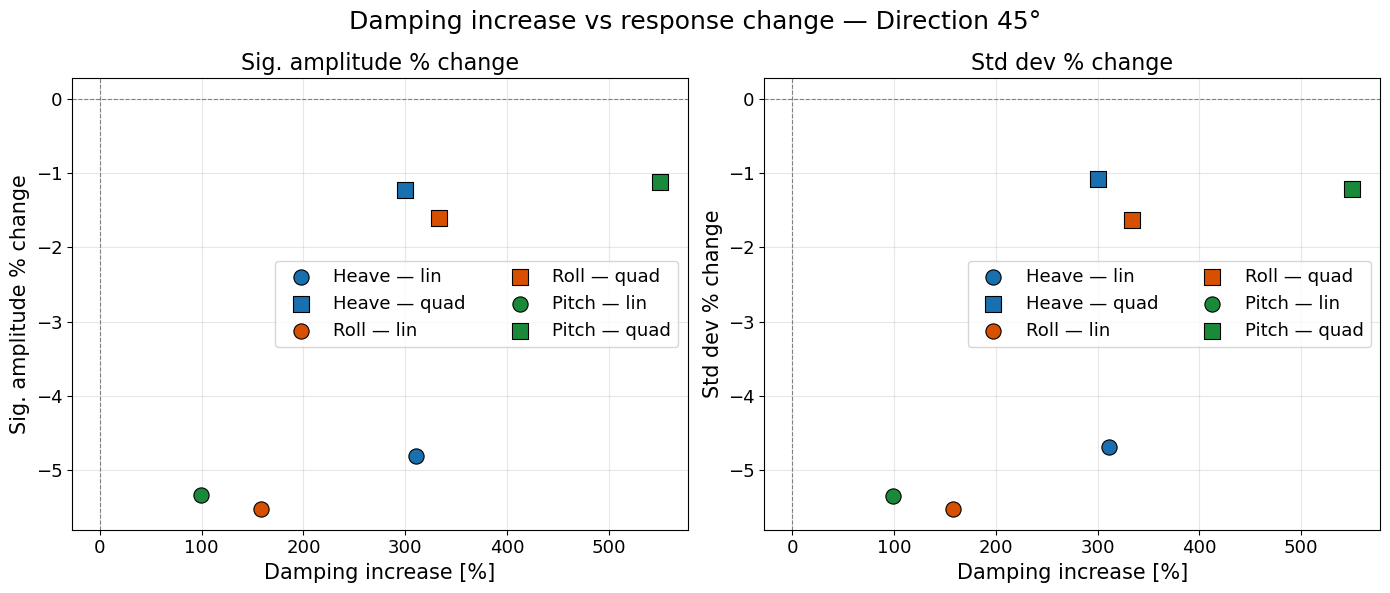

Saved: damp_vs_response_scatter_dir45.png


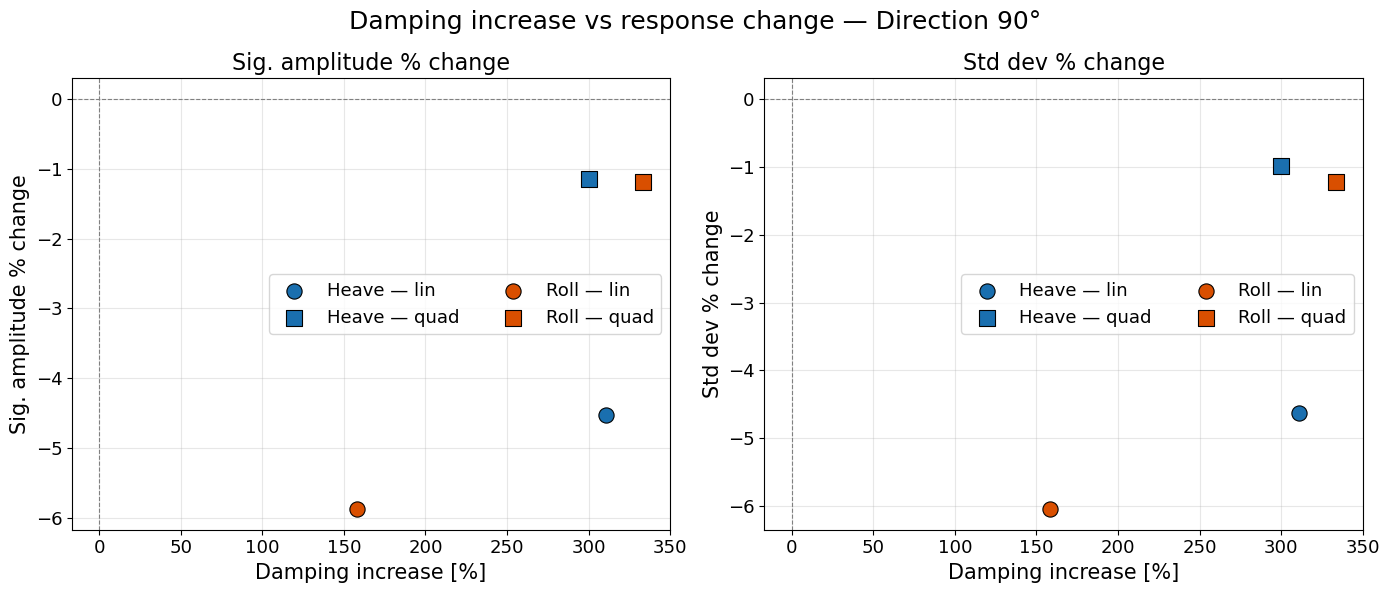

Saved: damp_vs_response_scatter_dir90.png


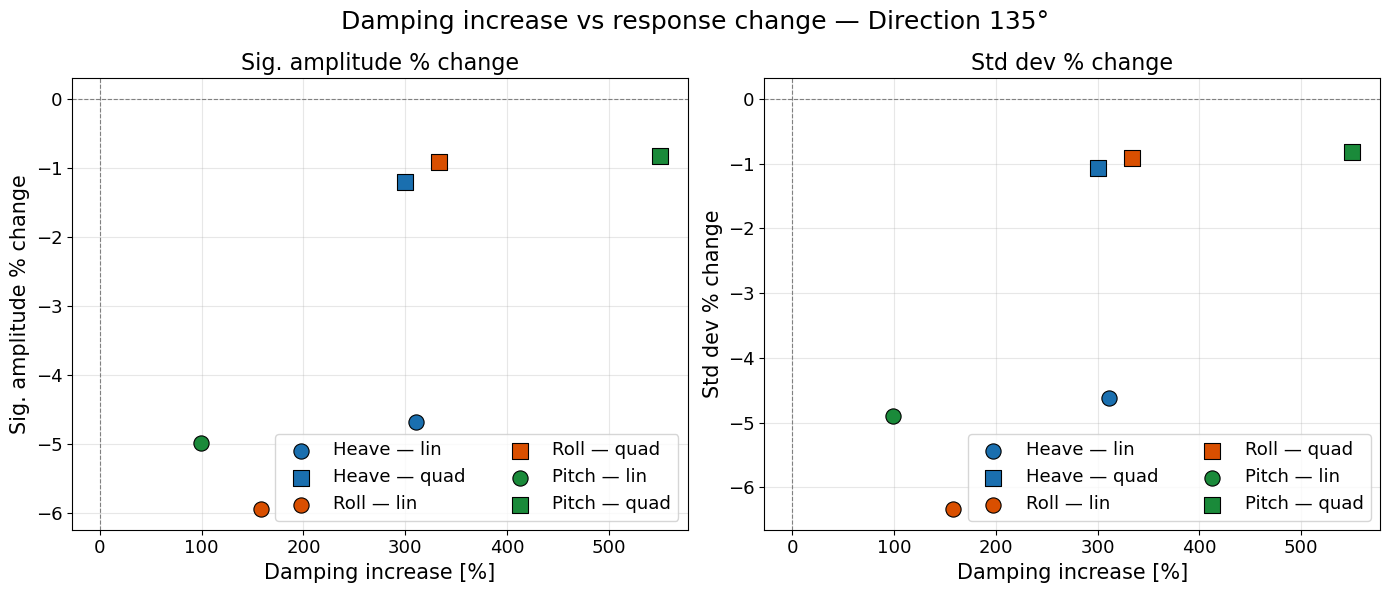

Saved: damp_vs_response_scatter_dir135.png


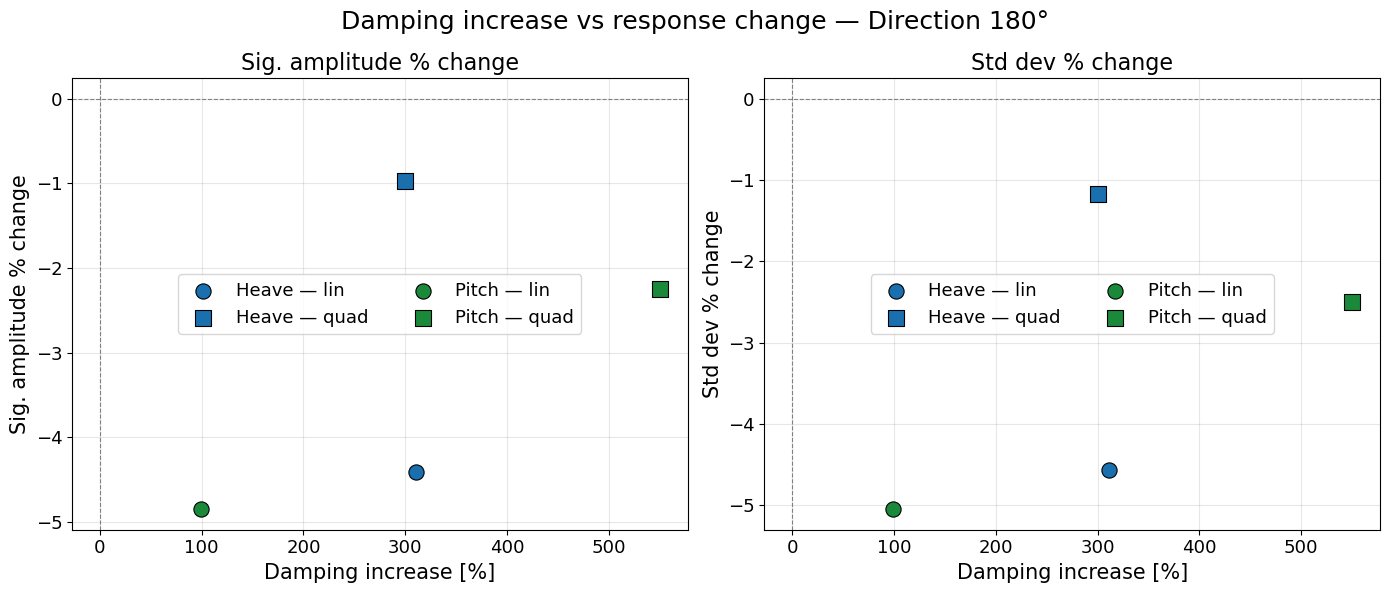

Saved: damp_vs_response_scatter_dir180.png


In [92]:
# ============================================================
# 16. Damping increase vs response change — scatter per direction
#     Color = DOF, marker = lin/quad
#     Left: sig. amplitude | Right: std
#     Roll excluded at dir=0,180 | Pitch excluded at dir=90
# ============================================================

RAD_DAMP = {'heave': 0.77, 'roll': 26.5, 'pitch': 26.4}

ref_case = results[
    (results['Damp_Heave'] == 'low') &
    (results['Damp_Roll']  == 'low') &
    (results['Damp_Pitch'] == 'low')
].iloc[0]

REF_LIN  = {
    'heave': ref_case['Lin_Heave']  + RAD_DAMP['heave'],
    'roll':  ref_case['Lin_Roll']   + RAD_DAMP['roll'],
    'pitch': ref_case['Lin_Pitch']  + RAD_DAMP['pitch'],
}
REF_QUAD = {
    'heave': ref_case['Quad_Heave'],
    'roll':  ref_case['Quad_Roll'],
    'pitch': ref_case['Quad_Pitch'],
}

DOF_CASES = {
    'heave': ['Heave_linhigh', 'Heave_quadhigh'],
    'roll':  ['Roll_linhigh',  'Roll_quadhigh'],
    'pitch': ['Pitch_linhigh', 'Pitch_quadhigh'],
}
LIN_COL  = {'heave': 'Lin_Heave',  'roll': 'Lin_Roll',  'pitch': 'Lin_Pitch'}
QUAD_COL = {'heave': 'Quad_Heave', 'roll': 'Quad_Roll', 'pitch': 'Quad_Pitch'}

DOF_COLOR   = {'heave': '#1a6faf', 'roll': '#d94f00', 'pitch': '#1a8a3a'}
TYPE_MARKER = {'linhigh': 'o', 'quadhigh': 's'}

DIR_SKIP_DOF_SCATTER = {0: ['roll'], 90: ['pitch'], 135: [], 45: [], 180: ['roll']}

for direction in sorted(results['Direction'].unique()):
    skip = DIR_SKIP_DOF_SCATTER.get(int(direction), [])
    active_dofs = [d for d in ['heave', 'roll', 'pitch'] if d not in skip]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
    fig.suptitle(f'Damping increase vs response change — Direction {int(direction)}°',
                 fontsize=TITLE_SIZE)

    for ax, (metric_key, metric_label) in zip(axes, [
        ('sig_amp', 'Sig. amplitude % change'),
        ('std',     'Std dev % change'),
    ]):
        for dof in active_dofs:
            metric_col = f'{dof}_sig_amp_pct' if metric_key == 'sig_amp' else f'{dof}_std_pct'

            for ct in DOF_CASES[dof]:
                damp_type = 'linhigh' if ct.endswith('linhigh') else 'quadhigh'

                sub = results[
                    (results['Direction'] == direction) &
                    (results.apply(case_type, axis=1) == ct)
                ]
                if len(sub) == 0:
                    continue

                if damp_type == 'linhigh':
                    damp_vals = sub[LIN_COL[dof]] + RAD_DAMP[dof]
                    damp_pct  = (damp_vals - REF_LIN[dof]) / REF_LIN[dof] * 100
                else:
                    if REF_QUAD[dof] == 0:
                        damp_pct = sub[QUAD_COL[dof]] - REF_QUAD[dof]
                    else:
                        damp_pct = (sub[QUAD_COL[dof]] - REF_QUAD[dof]) / REF_QUAD[dof] * 100

                mean_response = sub[metric_col].mean()
                mean_damp_pct = damp_pct.mean()

                ax.scatter(
                    mean_damp_pct, mean_response,
                    color=DOF_COLOR[dof],
                    marker=TYPE_MARKER[damp_type],
                    s=120,
                    edgecolors='black', linewidth=0.8,
                    zorder=3,
                    label=f'{dof.capitalize()} — {"lin" if damp_type == "linhigh" else "quad"}',
                )

        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.set_xlabel('Damping increase [%]', fontsize=LABEL_SIZE)
        ax.set_ylabel(metric_label, fontsize=LABEL_SIZE)
        ax.set_title(metric_label, fontsize=LABEL_SIZE + 1)
        ax.tick_params(labelsize=TICK_SIZE)
        ax.grid(True, alpha=0.3)

        handles, labels_leg = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_leg, handles))
        ax.legend(by_label.values(), by_label.keys(),
                  fontsize=TICK_SIZE, loc='best', ncol=2)

    plt.tight_layout()
    fname = PLOTS_DIR / f'damp_vs_response_scatter_dir{int(direction)}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {fname.name}')

## Done!

**Output files:**
- `analysis/sensitivity_results.xlsx` — all sims with sig. amp, std, % diff
- `analysis/sensitivity_summary.xlsx` — mean |% diff| per direction (tabs per direction)
- `analysis/sensitivity_ranking.xlsx` — cases ranked by response per DOF
- `analysis/plots/ts_bydof_*.png` — time series (centered around mean)
- `analysis/plots/barchart_*.png` — bar chart per seastate
- `analysis/plots/heatmap_summary_dir*.png` — heatmap per direction
- `analysis/plots/scatter_std_vs_sigamp.png` — scatter overview
- `analysis/plots/pct_vs_Tp_*.png` — % diff vs Tp
